<div style="text-align: center;">
    <img src="src/img/logo.png" alt="BoardGameGeek">
</div>

# Tabletop Games EDA

Los juegos de mesa son un campo con una gran expansion en las últimas dos décadas, por lo que se hace interesante estudiar las tendencias y evoluciones que se observan a día de hoy. Para ello, BoardGameGeek es una base de datos que recoge toda la información necesaria sobre los juegos de mesa a día de hoy, como puede ser el número de jugadores, tiempo medio de juego, dificultad, valoración, etc. Por ello, extraemos la información de la base de datos para poder hacer el análisis exploratorio lo más completo posible.


### Acceso a los datos (API)

Para ello, hemos utilizado la API oficial de BGG, [BGG XML API2](https://boardgamegeek.com/wiki/page/BGG_XML_API2), a través de la cual hemos accedido a todos los identificadores de la base de datos, gracias a la lista que obtenemos con [este enlace](https://boardgamegeek.com/data_dumps/bg_ranks) y que hemos almacenado como [boardgames_ranks.csv](src/data/boardgames_ranks.csv). El procedimiento que hemos seguido se recoge en el script [bgg_data_access.py](src/notebooks/bgg_data_access.py).

En primer lugar, importamos los módulos que nos van a hacer falta para todo el proceso de limpieza y análisis

In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import funciones as fn

In [2]:
# Estilo general
fondo_global = "#BDBDBD"
fondo_grafico = "#FBDDB8"
sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": fondo_global,
    "axes.facecolor": fondo_grafico,
    "axes.edgecolor": "black",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})

## Limpieza de datos

### Carga de datos

Hacemos la carga de todos los archivos json que tenemos en el apartado src/data/groups

In [3]:
# Cargar todos los archivos JSON de la carpeta src/data/groups
data_files = []  # lista para guardar el contenido de cada archivo JSON
for filename in os.listdir('src/data/groups'):
    # Procesar solo archivos con extensión .json
    if filename.endswith('.json'):
        with open(os.path.join('src/data/groups', filename), 'r', encoding='utf-8') as f:
            # Cargar el JSON y añadirlo a la lista
            data_files.append(json.load(f))

# Aplanar la lista de JSONs (cada archivo puede ser una lista o un objeto único)
# y construir un DataFrame a partir de los elementos
data = pd.DataFrame([
    item
    for sublist in data_files
    for item in (sublist if isinstance(sublist, list) else [sublist])
])

Revisamos el contenido de la tabla para poder filtrar que información es útil para el análisis

In [4]:
data.info()
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 176818 entries, 0 to 176817
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   row_id                176818 non-null  str   
 1   type                  176818 non-null  str   
 2   boardgame             176818 non-null  str   
 3   description           176780 non-null  str   
 4   min_players           176818 non-null  str   
 5   max_players           176818 non-null  str   
 6   suggested_numplayers  176818 non-null  object
 7   min_playtime          176818 non-null  str   
 8   max_playtime          176818 non-null  str   
 9   playingtime           176818 non-null  str   
 10  minimum_age           176818 non-null  str   
 11  release_year          176818 non-null  str   
 12  average_rating        176818 non-null  str   
 13  num_of_ratings        176818 non-null  str   
 14  weight                176818 non-null  str   
 15  num_of_weights        176818

,row_id,type,boardgame,description,min_players,max_players,suggested_numplayers,min_playtime,max_playtime,playingtime,...,categories,mechanisms,family,designers,artists,publishers,owned,trading,wanting,wishing
0,224517,boardgame,Brass: Birmingham,Brass: Birmingham is an economic strategy game...,2,4,"{'Best': '4', 'Recommended': '2', 'Not Recomme...",60,120,120,...,"[Age of Reason, Economic, Industry / Manufactu...","[Chaining, End Game Bonuses, Hand Management, ...","[Cities: Birmingham (England), Components: Map...","[Gavan Brown, Matt Tolman, Martin Wallace]","[Gavan Brown, Lina Cossette, David Forest, Gui...","[Roxley, Arclight Games, Board Game Rookie, Bo...",83744,367,1754,21874
1,342942,boardgame,Ark Nova,"In Ark Nova, you will plan and design a modern...",1,4,"{'Best': '2', 'Recommended': '3', 'Not Recomme...",90,150,150,...,"[Animals, Card Game, Environmental]","[Contracts, End Game Bonuses, Events, Grid Cov...","[Animals: Okapi, Components: Hexagonal Tiles, ...",[Mathias Wigge],"[Steffen Bieker, Loïc Billiau, Dennis Lohausen]","[Feuerland Spiele, Capstone Games, CMON Global...",88580,447,1071,17713
2,161936,boardgame,Pandemic Legacy: Season 1,Pandemic Legacy is a co-operative campaign gam...,2,4,"{'Best': '4', 'Recommended': '2', 'Not Recomme...",60,60,60,...,"[Environmental, Medical]","[Action Points, Cooperative Game, Hand Managem...","[Components: Map (Global Scale), Components: M...","[Rob Daviau, Matt Leacock]",[Chris Quilliams],"[Z-Man Games, Asterion Press, Devir, Filosofia...",89321,524,807,15019
3,174430,boardgame,Gloomhaven,Gloomhaven is a game of Euro-inspired tactica...,1,4,"{'Best': '3', 'Recommended': '2', 'Not Recomme...",60,120,120,...,"[Adventure, Exploration, Fantasy, Fighting, Mi...","[Action Queue, Action Retrieval, Campaign / Ba...","[Category: Dungeon Crawler, Components: Map (C...",[Isaac Childres],"[Alexandr Elichev, Lucile Mathieu, Josh T. McD...","[Cephalofair Games, Albi, Albi Polska, Arcligh...",104470,1306,1158,22286
4,397598,boardgame,Dune: Imperium – Uprising,"In Dune: Imperium Uprising, you want to contin...",1,6,"{'Best': '4', 'Recommended': '3', 'Not Recomme...",60,120,120,...,"[Movies / TV / Radio theme, Novel-based, Scien...","[Automatic Resource Growth, Card Play Conflict...","[Books: Dune, Game: Dune: Imperium, Misc: Long...",[Paul Dennen],"[Clay Brooks, Derek Herring, Raul Ramos, Nate ...","[Dire Wolf, Arclight Games, Broadway Toys LTD,...",28205,82,886,7794


### Eliminación de variables

- Observamos información redundante con max_playtime, min_playtime y playingtime, por lo que nos quedamos la última.
- La columna de family nos da información muy especifica que no parece aportar nada relevante por lo que la eliminamos. 
- Las columnas de trading y wanting se eliminan porque en este análisis solo tendremos en cuenta los juegos que la gente posee (owned) y los que los tienen en su lista de deseados (wishing) como parámetros a estudiar. 
- Eliminamos la descripción puesto que se trata de una sinopsis del juego que no nos aporta valor

In [ ]:
bgg_data = data.drop(["max_playtime", "min_playtime", "description", "family", 'trading', 'wanting'], axis=1)

### Conversion de datos

Convertimos a tipo númerico (ya sea int o float), las columnas necesarias

In [6]:
# Lista de columnas que deben convertirse a tipo numérico (int o float)
numericos = ['release_year', 'min_players', 'max_players', 'playingtime', 'minimum_age', 'num_of_ratings','weight', 
             'num_of_weights', 'average_rating', 'bayes_average', 'std_deviation','owned', 'wishing']

# Para cada columna, intentar convertir a numérico; si no es posible, poner NaN (errors='coerce')
for col in numericos:
    bgg_data[col] = pd.to_numeric(bgg_data[col], errors='coerce')

# Mostrar información del DataFrame (tipos de datos y conteo de valores no nulos)
bgg_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 176818 entries, 0 to 176817
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   row_id                176818 non-null  str    
 1   type                  176818 non-null  str    
 2   boardgame             176818 non-null  str    
 3   min_players           176818 non-null  int64  
 4   max_players           176818 non-null  int64  
 5   suggested_numplayers  176818 non-null  object 
 6   playingtime           176818 non-null  int64  
 7   minimum_age           176818 non-null  int64  
 8   release_year          176818 non-null  int64  
 9   average_rating        176818 non-null  float64
 10  num_of_ratings        176818 non-null  int64  
 11  weight                176818 non-null  float64
 12  num_of_weights        176818 non-null  int64  
 13  bayes_average         176818 non-null  float64
 14  std_deviation         176818 non-null  float64
 15  ranks      

No observamos de primeras ningún nulo, pero más adelante observaremos que hay valores imputados ya en la propia tabla, por lo que tendremos que considerar que hacer con ellos en el momento de usarlos.

### Creacion de tablas

Existen una serie de columnas que contienen datos tipo *object*, vamos a visualizar que son.

In [7]:
bgg_data[['suggested_numplayers','ranks', "categories", "mechanisms", "designers", "artists","publishers"]].head(5)

,suggested_numplayers,ranks,categories,mechanisms,designers,artists,publishers
0,"{'Best': '4', 'Recommended': '2', 'Not Recomme...","{'boardgame': '1', 'strategygames': '1'}","[Age of Reason, Economic, Industry / Manufactu...","[Chaining, End Game Bonuses, Hand Management, ...","[Gavan Brown, Matt Tolman, Martin Wallace]","[Gavan Brown, Lina Cossette, David Forest, Gui...","[Roxley, Arclight Games, Board Game Rookie, Bo..."
1,"{'Best': '2', 'Recommended': '3', 'Not Recomme...","{'boardgame': '2', 'strategygames': '2'}","[Animals, Card Game, Environmental]","[Contracts, End Game Bonuses, Events, Grid Cov...",[Mathias Wigge],"[Steffen Bieker, Loïc Billiau, Dennis Lohausen]","[Feuerland Spiele, Capstone Games, CMON Global..."
2,"{'Best': '4', 'Recommended': '2', 'Not Recomme...","{'boardgame': '3', 'thematic': '1', 'strategyg...","[Environmental, Medical]","[Action Points, Cooperative Game, Hand Managem...","[Rob Daviau, Matt Leacock]",[Chris Quilliams],"[Z-Man Games, Asterion Press, Devir, Filosofia..."
3,"{'Best': '3', 'Recommended': '2', 'Not Recomme...","{'boardgame': '4', 'thematic': '2', 'strategyg...","[Adventure, Exploration, Fantasy, Fighting, Mi...","[Action Queue, Action Retrieval, Campaign / Ba...",[Isaac Childres],"[Alexandr Elichev, Lucile Mathieu, Josh T. McD...","[Cephalofair Games, Albi, Albi Polska, Arcligh..."
4,"{'Best': '4', 'Recommended': '3', 'Not Recomme...","{'boardgame': '5', 'strategygames': '4'}","[Movies / TV / Radio theme, Novel-based, Scien...","[Automatic Resource Growth, Card Play Conflict...",[Paul Dennen],"[Clay Brooks, Derek Herring, Raul Ramos, Nate ...","[Dire Wolf, Arclight Games, Broadway Toys LTD,..."


Como vemos, todas son listas o diccionarios que contienen más de un dato en su interior, por lo que por comodidad, vamos a extraerlas en tablas aparte para así poder tener una tabla central con datos más pequeñas y usar estas tablas como anexos cuando se necesite. La columna de unión será el identificador único "row.id", que vamos a cambiar el nombre por "bgg.id"

Empezando por la listas de cadenas, vamos a utilizar la funcion *explode*.

In [8]:
# Renombrar la columna 'row_id' a 'bgg_id' para usarla como clave de unión
bgg_data.rename(columns={'row_id': 'bgg_id'}, inplace=True)

# Extraer la lista de diseñadores en una tabla separada (una fila por diseñador)
game_designers = bgg_data[['bgg_id','designers']].explode('designers')
# Eliminar la columna 'designers' del dataframe principal para evitar redundancia
bgg_data.drop(columns=['designers'], inplace=True)

# Extraer la lista de artistas en una tabla separada (una fila por artista)
game_artists = bgg_data[['bgg_id','artists']].explode('artists')
# Eliminar la columna 'artists' del dataframe principal
bgg_data.drop(columns=['artists'], inplace=True)

# Extraer las mecánicas en una tabla separada (una fila por mecánica)
game_mechanics = bgg_data[['bgg_id','mechanisms']].explode('mechanisms')
# Eliminar la columna 'mechanisms' del dataframe principal
bgg_data.drop(columns=['mechanisms'], inplace=True)

# Extraer las categorías en una tabla separada (una fila por categoría)
game_categories = bgg_data[['bgg_id','categories']].explode('categories')
# Eliminar la columna 'categories' del dataframe principal
bgg_data.drop(columns=['categories'], inplace=True)

# Extraer los editores/publicadores en una tabla separada (una fila por editor)
game_publishers = bgg_data[['bgg_id','publishers']].explode('publishers')
# Eliminar la columna 'publishers' del dataframe principal
bgg_data.drop(columns=['publishers'], inplace=True)

# Mostrar la forma (número de filas y columnas) del dataframe principal tras las operaciones
bgg_data.shape


(176818, 19)

Pasamos a los diccionarios, en el cual vamos a aprovecharnos de la funcion *json_normalize*, que nos va a extraer cada elemento del diccionario en una columna independiente. Después, lo uniremos con *concat* a los identificadores correspondientes.

In [9]:
# Expandir vectorizadamente la columna 'suggested_numplayers' (diccionarios -> columnas)
# Comentarios en castellano y manejo robusto de valores nulos/objetos vacíos.
suggested_col = 'suggested_numplayers'

# Sustituir valores no dict por diccionario vacío para evitar errores en json_normalize
tmp_series = bgg_data[suggested_col].apply(lambda x: x if isinstance(x, dict) else ({} if pd.isna(x) else x))
# Normalizar la serie de diccionarios a un DataFrame (cada clave del dict -> columna)
suggested_players_expanded = pd.json_normalize(tmp_series)
# Unir el identificador 'bgg_id' con las columnas expandidas en una tabla independiente
suggested_numplayers_table = pd.concat(
    [bgg_data[['bgg_id']].reset_index(drop=True), suggested_players_expanded.reset_index(drop=True)],
    axis=1
)
# Eliminar la columna original del dataframe principal para evitar redundancia
bgg_data.drop(columns=[suggested_col], inplace=True)
# Normalizar nombres de columnas (minúsculas y sin espacios)
suggested_numplayers_table.rename(columns=lambda c: str(c).strip().replace(' ', '_').lower(), inplace=True)

# Mostrar resultado resumido
suggested_numplayers_table.head(10)


,bgg_id,best,recommended,not_recommended
0,224517,4,2,1
1,342942,2,3,4+
2,161936,4,2,4+
3,174430,3,2,4+
4,397598,4,3,5
5,316554,3,2,4+
6,233078,6,5,1
7,115746,2,4,1
8,167791,3,2,5+
9,187645,2,4,1


In [10]:
# Normalizar la columna 'ranks' (diccionarios) y convertir a tipos numéricos de forma robusta
## Expandir los diccionarios en columnas individuales
ranks_expanded = pd.json_normalize(bgg_data['ranks'])
## Intentar convertir cada columna a entero nullable (Int64); fallos quedan como <NA>
ranks_expanded = ranks_expanded.apply(lambda col: pd.to_numeric(col, errors='coerce').astype('Int64'))


## Unir el identificador bgg_id con las columnas normalizadas de ranks
ranks_table = pd.concat([bgg_data[['bgg_id']].reset_index(drop=True), ranks_expanded.reset_index(drop=True)], axis=1)
## Ordenar por la columna 'boardgame' si existe (posición en el ranking)
if 'boardgame' in ranks_table.columns:
    ranks_table.sort_values(by='boardgame', inplace=True)

# Eliminar la columna original del dataframe principal para evitar redundancia
bgg_data.drop(columns=['ranks'], inplace=True)



En el caso del Rank, el puesto global si que es relevante, por lo que esa columna si que la añadiremos a la tabla global de nuevo. Renombramos algunas columnas para que se diferencien bien.

In [11]:
# bgg_data_merge= bgg_data.merge(ranks_table[['bgg_id','boardgame']], on='bgg_id', how='left')
bgg_data_merge= ranks_table[['bgg_id','boardgame']].merge(bgg_data, on='bgg_id', how='right')
bgg_data_merge.rename(columns={'boardgame_x': 'rank','boardgame_y': 'name'}, inplace=True)
bgg_data_merge.sort_values(by='rank', inplace=True, ascending=True)
bgg_data= bgg_data_merge.copy()
bgg_data.head(10)

,bgg_id,rank,type,name,min_players,max_players,playingtime,minimum_age,release_year,average_rating,num_of_ratings,weight,num_of_weights,bayes_average,std_deviation,language_dependency,owned,wishing
0,224517,1,boardgame,Brass: Birmingham,2,4,120,14,2018,8.56433,58318,3.8607,2850,8.39353,1.42790,1: No necessary in-game text,83744,21874
1,342942,2,boardgame,Ark Nova,1,4,150,14,2021,8.54058,60867,3.7963,3118,8.35456,1.40476,4: Extensive use of text - massive conversion ...,88580,17713
2,161936,3,boardgame,Pandemic Legacy: Season 1,2,4,60,13,2015,8.50255,57354,2.8278,1556,8.34628,1.60876,4: Extensive use of text - massive conversion ...,89321,15019
3,174430,4,boardgame,Gloomhaven,1,4,120,14,2017,8.53957,67111,3.9187,2755,8.29747,1.73643,4: Extensive use of text - massive conversion ...,104470,22286
4,397598,5,boardgame,Dune: Imperium – Uprising,1,6,120,13,2023,8.70003,18269,3.5243,576,8.23575,1.33245,3: Moderate in-game text - needs crib sheet or...,28205,7794
5,316554,6,boardgame,Dune: Imperium,1,4,120,14,2020,8.41222,58264,3.0768,2056,8.22242,1.29048,3: Moderate in-game text - needs crib sheet or...,77755,15563
6,233078,7,boardgame,Twilight Imperium: Fourth Edition,3,6,480,14,2017,8.56424,28349,4.3539,1393,8.21911,1.64725,4: Extensive use of text - massive conversion ...,33735,13049
7,115746,8,boardgame,War of the Ring: Second Edition,2,4,240,13,2011,8.55226,25078,4.2239,1380,8.19844,1.48079,4: Extensive use of text - massive conversion ...,41474,13010
8,167791,9,boardgame,Terraforming Mars,1,5,120,12,2016,8.33804,113026,3.2713,4648,8.18708,1.43051,4: Extensive use of text - massive conversion ...,159431,27010
9,187645,10,boardgame,Star Wars: Rebellion,2,4,240,14,2016,8.42185,36332,3.7535,1278,8.16701,1.36219,4: Extensive use of text - massive conversion ...,57374,14975


### Filtros de selección

Procedemos a poner una serie de filtros para obtener información que sea fiable y con la que podamos trabajar con mayor facilidad.

In [ ]:
# Guardamos el número de filas antes de aplicar los filtros para poder comparar después
filas_prefiltro = bgg_data.shape[0]
print(f"Filas antes de aplicar filtros: {filas_prefiltro}")

# Filtramos juegos con un número máximo de jugadores razonable (<40)
bgg_data = bgg_data[(bgg_data["max_players"]<=40)]
print(f"Filas después de filtrar por máximo de jugadores: {bgg_data.shape[0]}")

# Filtramos juegos con duración (playingtime) plausibles (<1440 minutos, es decir, menos de 24 horas) y mayor a 0
bgg_data = bgg_data[(bgg_data["playingtime"]<1440) & (bgg_data["playingtime"]>0)]
print(f"Filas después de filtrar por duración: {bgg_data.shape[0]}")

# Filtramos juegos con edad mínima razonable (<22 años)
bgg_data = bgg_data[(bgg_data["minimum_age"]<22)]
print(f"Filas después de filtrar por edad mínima: {bgg_data.shape[0]}")

# Excluimos registros con años de lanzamiento futuros (<= 2026)
bgg_data = bgg_data[(bgg_data["release_year"]<=2026)]
print(f"Filas después de filtrar por año de lanzamiento: {bgg_data.shape[0]}")

# Exigimos un mínimo de valoraciones para mayor robustez (>30)
bgg_data = bgg_data[(bgg_data["num_of_ratings"]>30)]
print(f"Filas después de filtrar por número de valoraciones: {bgg_data.shape[0]}")

# Excluimos juegos sin valoración promedio  y peso validos (>0)
bgg_data = bgg_data[(bgg_data["average_rating"]>0) & (bgg_data["weight"]>0)]
print(f"Filas después de filtrar por valoración y peso: {bgg_data.shape[0]}")

# Contamos las filas después de aplicar los filtros
filas_postfiltro = bgg_data.shape[0]

# Mostramos resumen del efecto de los filtros: antes, después, eliminadas y porcentaje eliminado
print(f"\nFilas antes del filtro: {filas_prefiltro}")
print(f"Filas después del filtro: {filas_postfiltro}")
print(f"Filas eliminadas: {filas_prefiltro - filas_postfiltro}")
print(f"Porcentaje de filas eliminadas: {((filas_prefiltro - filas_postfiltro) / filas_prefiltro) * 100:.2f}%")

Filas antes de aplicar filtros: 176818
Filas después de filtrar por máximo de jugadores: 173008
Filas después de filtrar por duración: 135719
Filas después de filtrar por edad mínima: 135671
Filas después de filtrar por año de lanzamiento: 135318
Filas después de filtrar por número de valoraciones: 38348
Filas después de filtrar por valoración y peso: 35925

Filas antes del filtro: 176818
Filas después del filtro: 35925
Filas eliminadas: 140893
Porcentaje de filas eliminadas: 79.68%


Se observa que había una gran cantidad de información que estaba incompleta o con valores que no nos aportaban información. En concreto, la propia BGG establece que un juego no puede tener valoraciones si no tiene al menos 30 reviews, por lo que el filtro por número de ratings y por average_rating son los que más afectan a esta tabla. Nos quedamos con un 20.32% del total de la base de datos, que sigue representando **35925 juegos**.

### Separación en juegos y expansiones

Si revisamos el tipo podremos ver que existe principalmente 2 categorias: juego y expansion.

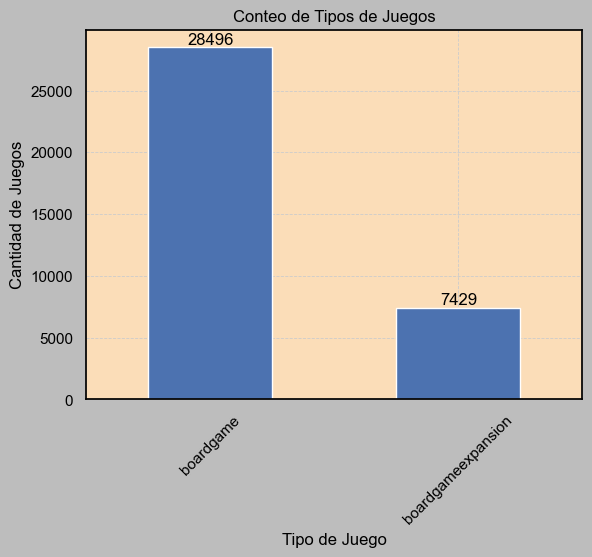

In [54]:
conteo_tipos = bgg_data['type'].value_counts()
ax = conteo_tipos.plot(kind='bar', rot=45)
ax.bar_label(ax.containers[0])
plt.title('Conteo de Tipos de Juegos') 
plt.xlabel('Tipo de Juego')
plt.ylabel('Cantidad de Juegos')
plt.show()

Se observa que la mayoría son juegos. Además, según la documentación de la BGG, de manera intrinseca las expansiones de juegos no tienen ranking, debido a su naturaleza de que están enlazadas obligatoriamente a un juego base y por tanto, las valoraciones siempre son de acuerdo al juego base. Esta situación da lugar a sesgos bastante importantes de los que es mejor prescindir para evitar conflictos, así que decidimos guardar en tablas diferentes por si en algún momento dedicidimos retomar el análisis centrandonos en expansiones.

In [14]:
bgg_expansions = bgg_data[bgg_data['type'] == 'boardgameexpansion'].copy()
bgg_games = bgg_data[bgg_data['type'] == 'boardgame'].copy()
print(f"Cantidad de juegos base: {bgg_games.shape[0]}")
print(f"Cantidad de expansiones: {bgg_expansions.shape[0]}")

Cantidad de juegos base: 28496
Cantidad de expansiones: 7429


### Exportar tablas

Finalmente, guardamos toda la información que hemos filtrado en archivos *csv*, para así no tener que depender de los datos crudos iniciales cada vez que se necesite cargar los datos.

In [16]:
# Exportar las tablas principales a archivos CSV
bgg_games.to_csv('src/data/tables/bgg_games.csv', index=False)
bgg_expansions.to_csv('src/data/tables/bgg_expansions.csv', index=False)

# Exportar las tablas de relaciones y atributos
ranks_table.to_csv('src/data/tables/ranks_table.csv', index=False)
suggested_numplayers_table.to_csv('src/data/tables/suggested_numplayers_table.csv', index=False)

# Exportar las tablas de muchos-a-muchos (artistas, diseñadores, mecánicas, etc.)
game_designers.to_csv('src/data/tables/game_designers.csv', index=False)
game_artists.to_csv('src/data/tables/game_artists.csv', index=False)
game_mechanics.to_csv('src/data/tables/game_mechanics.csv', index=False)
game_categories.to_csv('src/data/tables/game_categories.csv', index=False)
game_publishers.to_csv('src/data/tables/game_publishers.csv', index=False)

# Mensaje de confirmación de que todos los archivos se han exportado correctamente
print("¡Todas las tablas se han exportado correctamente!")

¡Todas las tablas se han exportado correctamente!


## Análisis de datos

En primer lugar, cargamos los datos directamente del archivo externo, para evitar tener que hacer todos los pasos previos a éste y así ahorrar en tiempo y memoria.

In [17]:
# Carga la tabla principal de juegos (bgg_games.csv) usando la función cargar_tabla_juegos
bgg_games = fn.cargar_tabla_juegos('bgg_games')

# Carga las tablas de relaciones muchos-a-muchos:
# artistas, diseñadores, mecánicas y categorías (cada una desde su CSV correspondiente)
game_artists = fn.cargar_tabla_juegos('game_artists')
game_designers = fn.cargar_tabla_juegos('game_designers')
game_mechanics = fn.cargar_tabla_juegos('game_mechanics')
game_categories = fn.cargar_tabla_juegos('game_categories')



Cargando tabla desde archivo: src/data/tables/bgg_games.csv
Cargando tabla desde archivo: src/data/tables/game_artists.csv
Cargando tabla desde archivo: src/data/tables/game_designers.csv
Cargando tabla desde archivo: src/data/tables/game_mechanics.csv
Cargando tabla desde archivo: src/data/tables/game_categories.csv


De aquí en adelante, crearemos copia de las tablas originales para evitar modificarlas.

In [18]:
bgg_juegos = bgg_games.copy()

bgg_artistas = game_artists.copy()
bgg_disenadores = game_designers.copy()
bgg_mecanicas = game_mechanics.copy()
bgg_categorias = game_categories.copy()

### Cardinalidad y nulos

En primer lugar, estudiaremos los valores nulos de las variables que tenemos.

In [19]:
# Estudio de valores nulos
valores_nulos = bgg_juegos.isnull().sum()
print("\nValores nulos en cada variable:")
print(valores_nulos)


Valores nulos en cada variable:
bgg_id                   0
rank                   546
type                     0
name                     0
min_players              0
max_players              0
playingtime              0
minimum_age              0
release_year             0
average_rating           0
num_of_ratings           0
weight                   0
num_of_weights           0
bayes_average            0
std_deviation            0
language_dependency      0
owned                    0
wishing                  0
dtype: int64


In [20]:
# Detectar filas donde 'rank' es nulo y guardarlo en una serie booleana
rank_nulos = bgg_juegos['rank'].isnull()
bgg_juegos[rank_nulos].head()


,bgg_id,rank,type,name,min_players,max_players,playingtime,minimum_age,release_year,average_rating,num_of_ratings,weight,num_of_weights,bayes_average,std_deviation,language_dependency,owned,wishing
27950,622,NaN,boardgame,Change!,2,8,30,10,1999,5.27484,161,1.2105,19,5.48387,1.33123,1: No necessary in-game text,434,7
27951,2802,NaN,boardgame,War in Europe,2,3,360,14,1976,7.23359,198,3.7143,14,5.61250,1.76938,3: Moderate in-game text - needs crib sheet or...,496,77
27952,2883,NaN,boardgame,The Book of Classic Board Games,1,4,10,6,1991,6.60078,280,1.8333,18,5.61001,1.46643,2: Some necessary text - easily memorized or s...,596,42
27953,3042,NaN,boardgame,Survival / The Barbarian,1,6,30,8,1979,5.18594,64,1.2000,5,5.48889,1.79643,1: No necessary in-game text,219,21
27954,3694,NaN,boardgame,Great Medieval Battles: Four Battles from the ...,2,2,240,12,1979,6.93571,112,2.3077,13,5.55781,1.42032,3: Moderate in-game text - needs crib sheet or...,365,46


Tenemos unos valores *NaN* en una columna de integers. Existen varios enfoques: podemos imputar un valor numerico fuera del rango para evitar que afecte a los datos; podemos dejarlo como está y simplemente ignorarlo cuando estemos usandolo; o eliminar las filas con datos. Puesto que el porcentaje de nulos es bajo, optamos por la segunda opción para evitar que la imputación nos puedas modificar ese dato, sin perder el resto de información.

Calculamos la cardinalidad

In [21]:
# Estudio de cardinalidad de las variables
cardinalidad = bgg_juegos.nunique()/len(bgg_juegos)*100
print("Cardinalidad de cada variable:")
print(cardinalidad)

Cardinalidad de cada variable:
bgg_id                 100.000000
rank                    98.083942
type                     0.003509
name                    98.126053
min_players              0.038602
max_players              0.126334
playingtime              0.354436
minimum_age              0.070185
release_year             0.677288
average_rating          92.721786
num_of_ratings          13.679113
weight                  16.374228
num_of_weights           3.056569
bayes_average           65.009124
std_deviation           85.787479
language_dependency      0.021056
owned                   19.051797
wishing                  8.039725
dtype: float64


Se observa una cardinalidad bastante alta en rank y name, pero no es 100% como el identificador, por lo que existiran nombres que se repiten entre diferentes reimplementaciones de un mismo juego. Con el rank ya hemos visto que hay una pequeña parte de nulos que hemos decidido no cambiar para evitar que altere los calculos y no borrar el resto de información que puede ser relevante.

En el caso de average_rating y el bayes_average, al ser una variable continua con muchos decimales, se observa que existe una cardinalidad alta, suele ser dificil que con tantos decimales haya números repetidos pero aun así existe juegos con la misma valoración.

### Análisis monovariante

Para el análisis monovariante, vamos a eliminar aquellas variables que tienen una alta cardinalidad, como son el rank, el nombre y el id. También eliminamos el type, porque solo tiene un unico valor, es una columna residual de cuando teniamos las expansiones.

In [22]:
bgg_juegos_monovariante = bgg_juegos.copy()
bgg_juegos_monovariante.drop(columns=['bgg_id','type','name', 'rank'], inplace=True)
bgg_juegos_monovariante.head()

,min_players,max_players,playingtime,minimum_age,release_year,average_rating,num_of_ratings,weight,num_of_weights,bayes_average,std_deviation,language_dependency,owned,wishing
0,2,4,120,14,2018,8.56433,58318,3.8607,2850,8.39353,1.42790,1: No necessary in-game text,83744,21874
1,1,4,150,14,2021,8.54058,60867,3.7963,3118,8.35456,1.40476,4: Extensive use of text - massive conversion ...,88580,17713
2,2,4,60,13,2015,8.50255,57354,2.8278,1556,8.34628,1.60876,4: Extensive use of text - massive conversion ...,89321,15019
3,1,4,120,14,2017,8.53957,67111,3.9187,2755,8.29747,1.73643,4: Extensive use of text - massive conversion ...,104470,22286
4,1,6,120,13,2023,8.70003,18269,3.5243,576,8.23575,1.33245,3: Moderate in-game text - needs crib sheet or...,28205,7794


Hacemos la clasificación de las variables segun su tipo, usando una funcion que hemos desarrollado y que se encuentren [utils](src/utils/funciones.py).

In [23]:
clasificaciones = []
for col in bgg_juegos_monovariante.columns:
    s = bgg_juegos_monovariante[col]
    clas = fn.clasificar_columna(s, 30)
    clasificaciones.append({
        'variable': col,
        'dtype': str(s.dtype),
        'n_unique': int(s.nunique(dropna=True)),
        'classification': clas
    })

pd.DataFrame(clasificaciones).set_index('variable')


,dtype,n_unique,classification
variable,,,
min_players,int64,11,numerico_discreto
max_players,int64,36,numerico_continuo
playingtime,int64,101,numerico_continuo
minimum_age,int64,20,numerico_discreto
release_year,int64,193,numerico_continuo
average_rating,float64,26422,numerico_continuo
num_of_ratings,int64,3898,numerico_continuo
weight,float64,4666,numerico_continuo
num_of_weights,int64,871,numerico_continuo


En el caso de *language_dependency* aparecen seis categorias en vez de las 5 previstas, por lo que revisamos los valores

In [24]:
# Contar las ocurrencias de cada valor en la columna 'language_dependency'
language_dependency_counts = bgg_juegos_monovariante['language_dependency'].value_counts()
print(language_dependency_counts)

# Crear una máscara booleana para detectar filas cuyo valor de 'language_dependency' sea la cadena "{}"
log_lenguaje = bgg_juegos_monovariante['language_dependency'] == "{}"

# Eliminar de bgg_juegos las filas que cumplen la condición (filas con "{}")
bgg_juegos = bgg_juegos[~log_lenguaje]

# Eliminar de bgg_juegos_monovariante las mismas filas
bgg_juegos_monovariante = bgg_juegos_monovariante[~log_lenguaje]

# Mostrar el nuevo conteo de valores en 'language_dependency' tras la limpieza
print(bgg_juegos_monovariante['language_dependency'].value_counts())

language_dependency
1: No necessary in-game text                                           16422
3: Moderate in-game text - needs crib sheet or paste ups                5124
2: Some necessary text - easily memorized or small crib sheet           3459
4: Extensive use of text - massive conversion needed to be playable     2663
5: Unplayable in another language                                        827
{}                                                                         1
Name: count, dtype: int64
language_dependency
1: No necessary in-game text                                           16422
3: Moderate in-game text - needs crib sheet or paste ups                5124
2: Some necessary text - easily memorized or small crib sheet           3459
4: Extensive use of text - massive conversion needed to be playable     2663
5: Unplayable in another language                                        827
Name: count, dtype: int64


Pasamos a representar las variables discretas. Para ello, hemos definido unas funciones que nos permiten crear y mostrar los gráficos para variables numericas discretas.

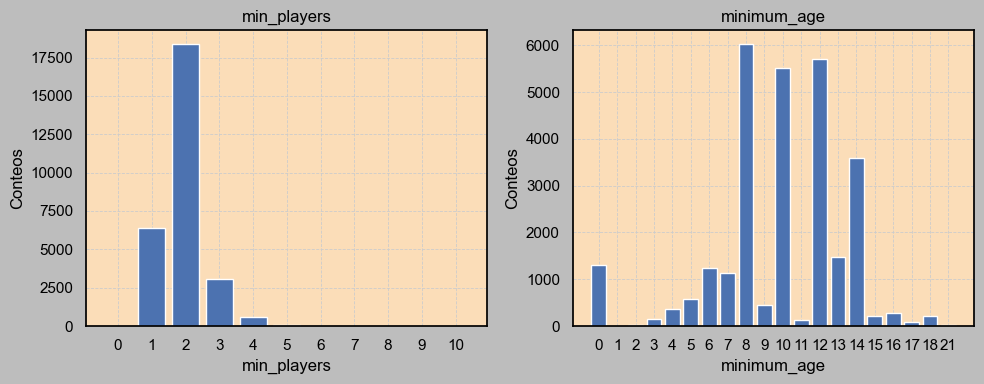

In [25]:
graficos_discretos = fn.crear_graficos_discretos(bgg_juegos_monovariante, clasificaciones)
fn.mostrar_graficos_discretos(graficos_discretos,figsize=(10, 4), ncols=2)


Se observa que existe un gran sesgo en el número mínimo de jugadores, siendo mayormente 2, aunque existe un gran número de juegos con juego en solitario.

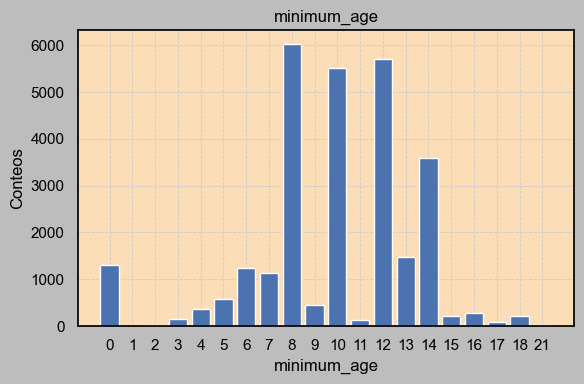

In [26]:
fn.mostrar_graficos_discretos(graficos_discretos,var='minimum_age',figsize=(8, 4))

En el caso de la edad minima, vemos que existe una tendencia a clasificarlo en 4 edades diferentes: 8, 10, 12 y 14.

Pasamos al estudio de las variables continuas. Al igual que antes, hemos desarrollado una serie de funciones para crear y mostrar las gráficas, en este caso se muesta un histograma con densidad y un boxplot por cada variable.

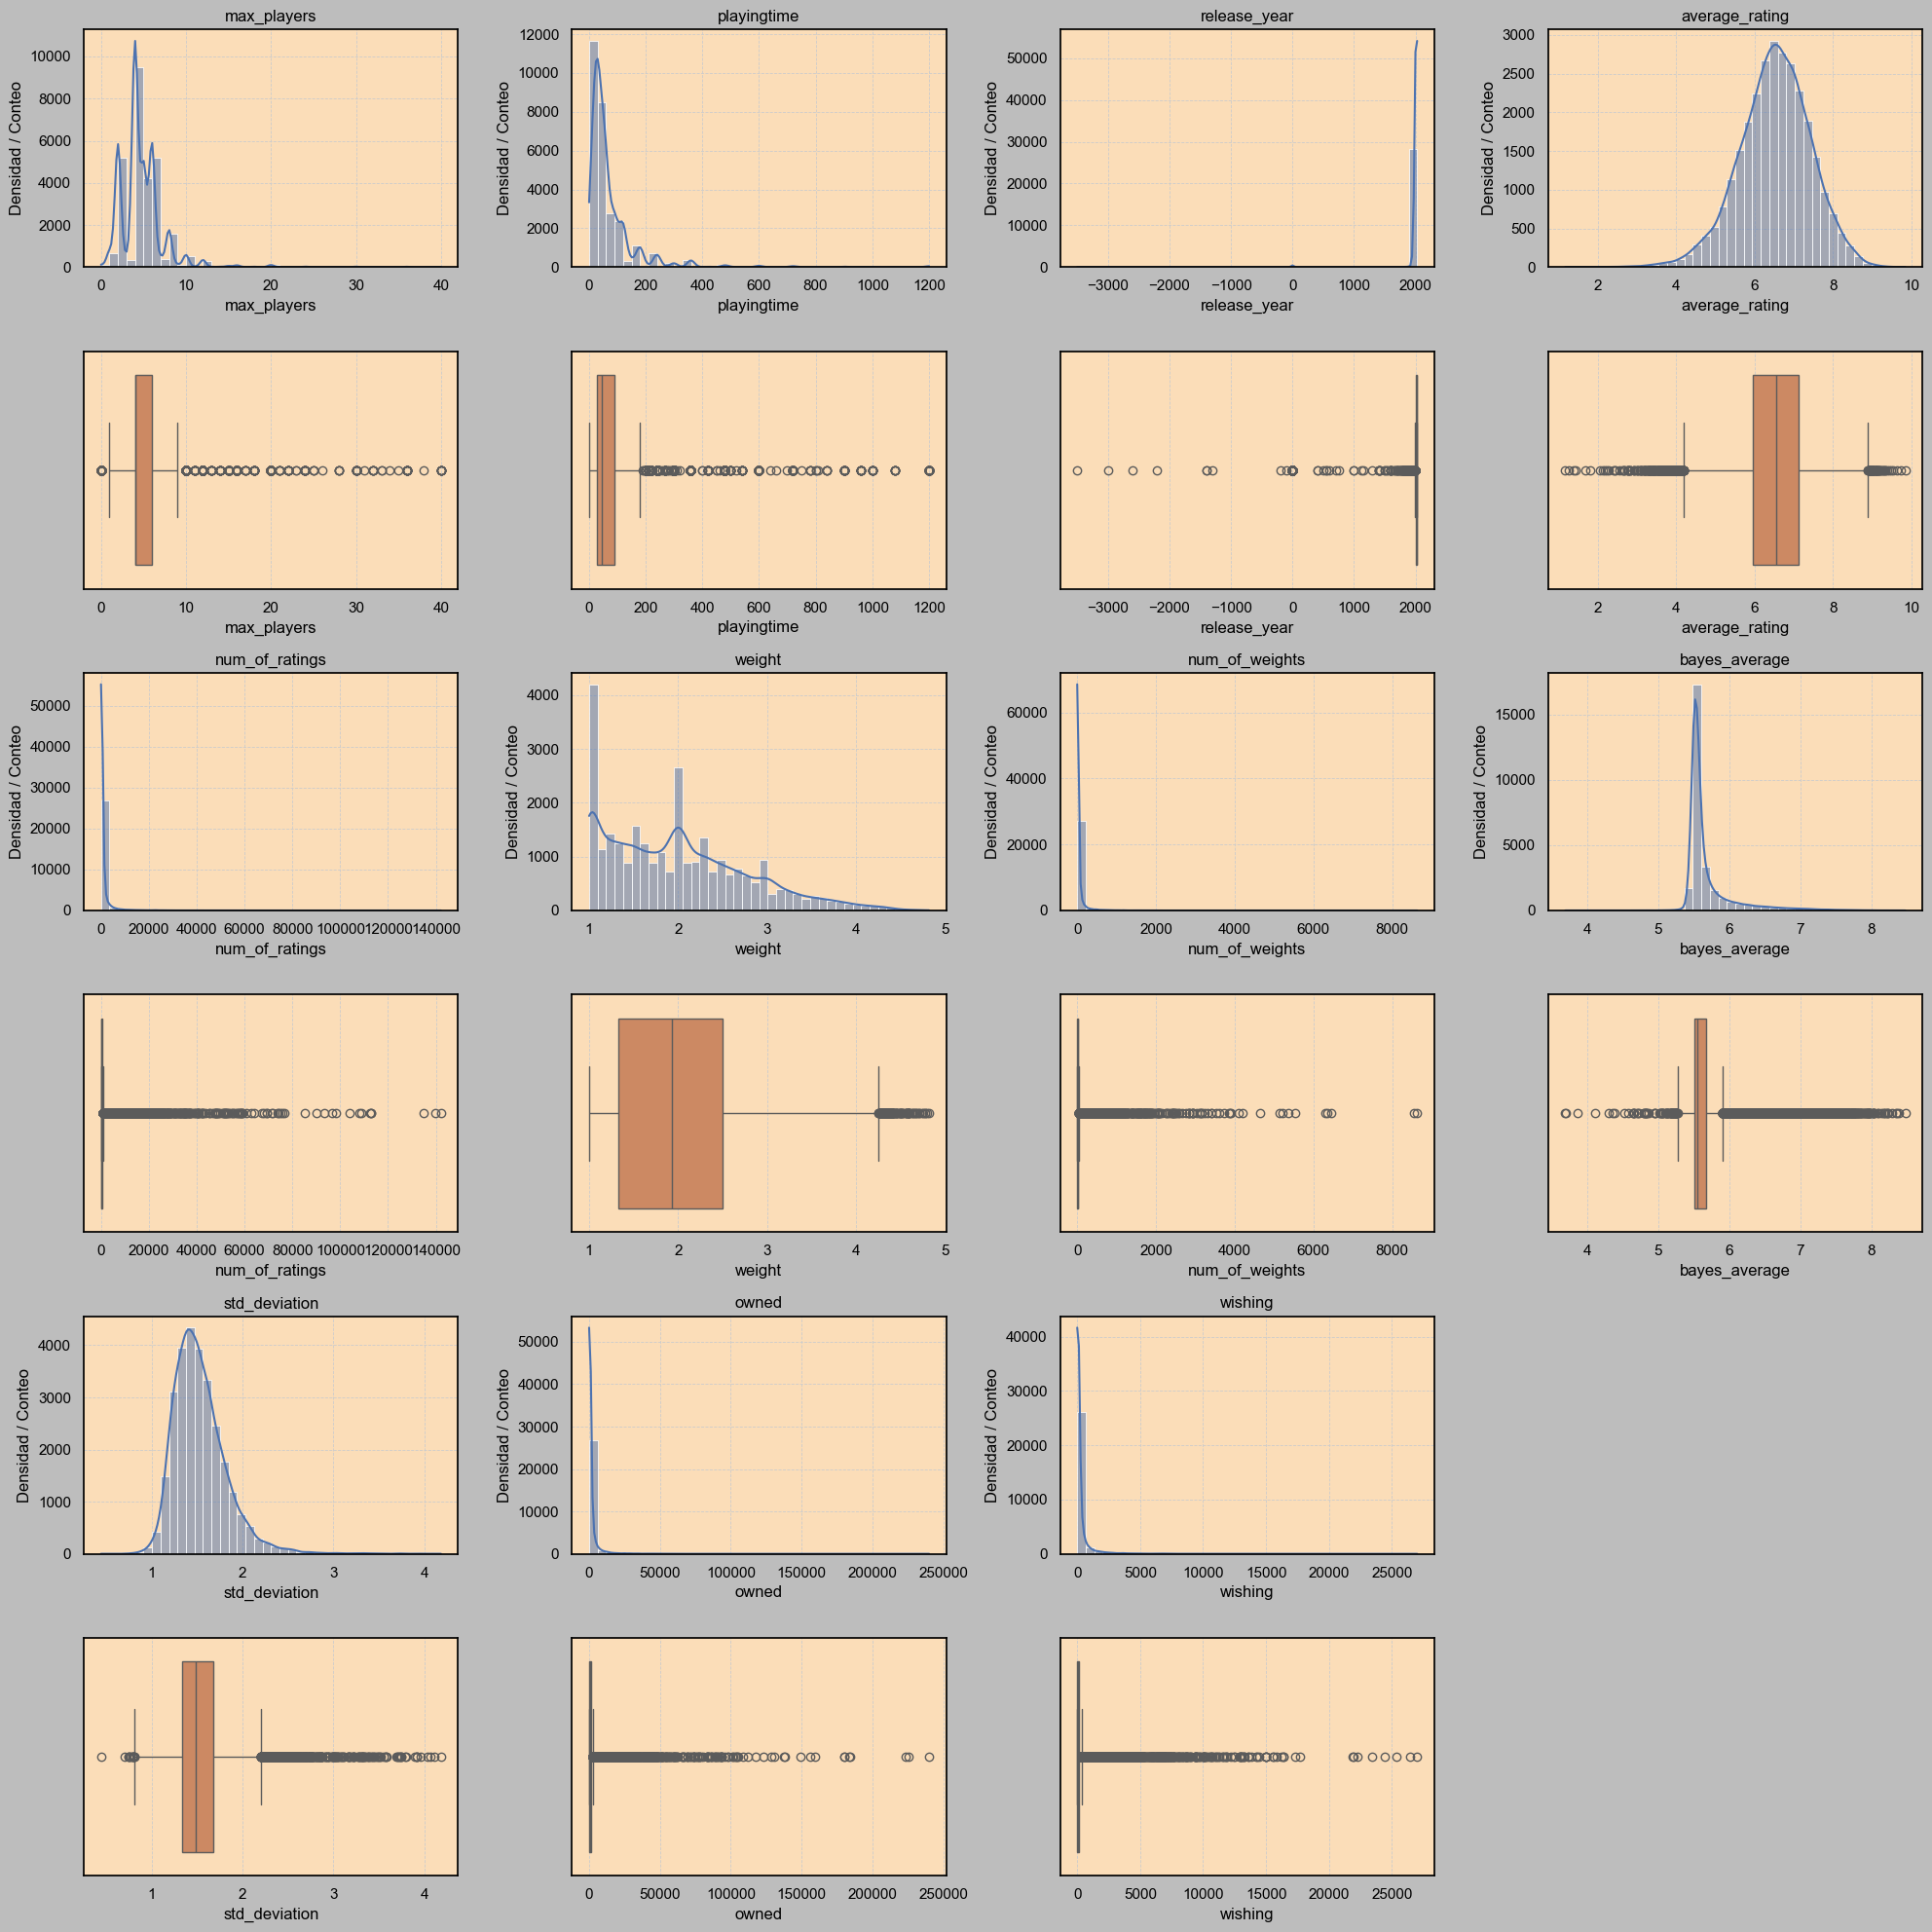

In [27]:
graficos_continuos = fn.crear_graficos_continuos(bgg_juegos_monovariante, clasificaciones)
fn.mostrar_graficos_continuos(graficos_continuos, figsize=(20,20), ncols=4)

En el caso de las variables continuas, observamos que existen muchas de ellas que tienen valores muy extremos que desvirtuan la distribución, como puede ser el caso de *num_of_ratings*, *num_of_weights*, *playingtime*, *owned*, *wishing*. Hay un caso particular que es el caso de *release_year*, que se observa que el minimo muy alejado del resto. Estudiemos su distribución.

In [28]:
bgg_juegos_monovariante['release_year'].describe()


count    28495.000000
mean      1996.564274
std        170.582038
min      -3500.000000
25%       2005.000000
50%       2015.000000
75%       2020.000000
max       2026.000000
Name: release_year, dtype: float64

In [29]:
bgg_juegos.sort_values('release_year').head(1)

,bgg_id,rank,type,name,min_players,max_players,playingtime,minimum_age,release_year,average_rating,num_of_ratings,weight,num_of_weights,bayes_average,std_deviation,language_dependency,owned,wishing
11318,2399,11604.0,boardgame,Senet,2,2,30,6,-3500,5.82311,936,1.4384,73,5.5664,1.6846,1: No necessary in-game text,1859,205


El valor minimo es de 3500 antes de Cristo, pertence a un juego del antiguo Egipto llamado Senet. Sin embargo, cuando miramos su distribución, la media es 1996 y el primer cuartil es de 2005, por lo que tendría mas sentido hacer el análisis de la progresion de los juegos respecto al año a partir de los años 90s

<BarContainer object of 37 artists>

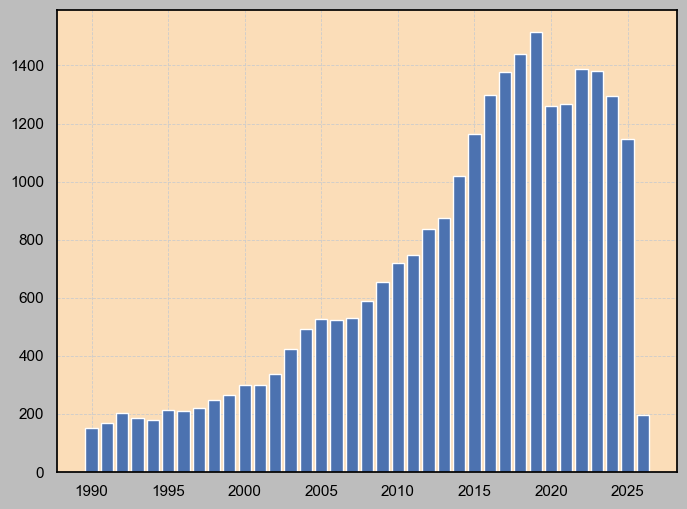

In [30]:
log_año = bgg_juegos_monovariante['release_year'] >= 1990
conteos = bgg_juegos_monovariante[log_año]['release_year'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 6))
plt.bar(conteos.index, conteos.values)

En el caso de las variables categóricas, solo existe una, que es la dependencia del idioma.

<Axes: xlabel='language_dependency'>

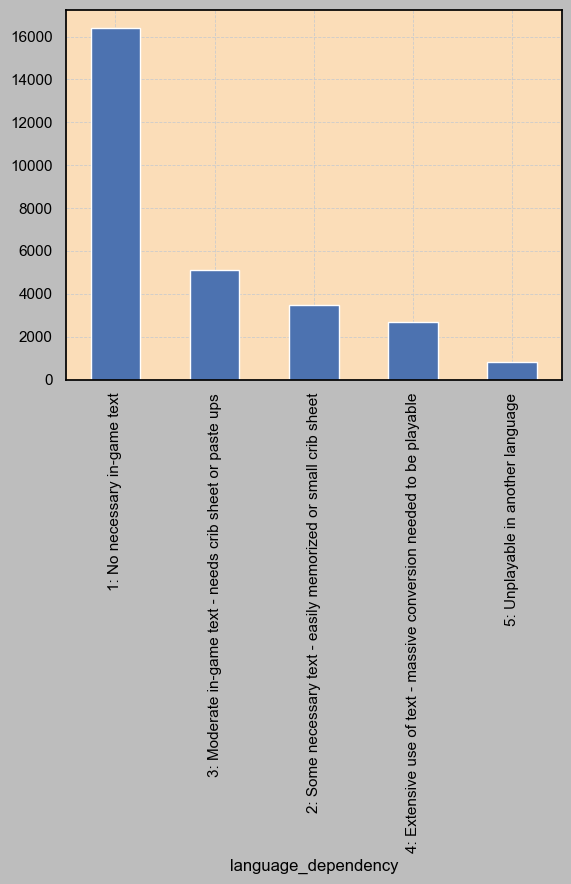

In [31]:
bgg_juegos_monovariante['language_dependency'].value_counts().plot(kind='bar')

Se observa que abundan sobre todo juegos independientes del idioma, por lo que es una cualidad que deberíamos intentar buscar en nuestro juego.

#### Variables relevantes de la tabla principal

Las variables que pueden tener más interés de cara a los análisis de futuros productos son: minimo y máximo de jugadores, edad mínima y dificultad (peso).

In [32]:
df_analysis = bgg_juegos[['min_players', 'max_players', 'minimum_age','weight',]]
print("\n\nMedia de variables numéricas:")
media_bgg = df_analysis.mean()
moda_bgg = df_analysis.mode().loc[0]
mediana_bgg = df_analysis.median()
# creamos una unica tabla para mostrar media, moda y mediana
estadisticas_bgg = pd.DataFrame({'Media': media_bgg, 'Moda': moda_bgg, 'Mediana': mediana_bgg})
print(estadisticas_bgg)



Media de variables numéricas:
                Media  Moda  Mediana
min_players  1.940726   2.0   2.0000
max_players  4.738831   4.0   4.0000
minimum_age  9.837480   8.0  10.0000
weight       1.981049   1.0   1.9259


En el caso del número de jugadores, observamos que la tendencia es de 2 a 4 jugadores, con la media dando a entender que podria llegar a ser 2 a 5 jugadores. En el caso de la edad minima, la media y la mediana nos lo establecen cerca de los 10 años, lo que corresponde con el gráfico que hemos enseñado previamente. Por último, en cuanto al peso, no estamos situando en una juego de dificultad media-baja, en torno al 2 de peso.

#### Categorias, mecánicas, artistas y diseñadores

In [33]:
print("\nArtistas:")
print(bgg_artistas['artists'].value_counts().head(10))
print("\nDiseñadores:")
print(bgg_disenadores['designers'].value_counts().head(10))
print("\nCategorías:")
print(bgg_categorias['categories'].value_counts().head(10))
print("\nMecánicas:")
print(bgg_mecanicas['mechanisms'].value_counts().head(10))


Artistas:
artists
(Uncredited)              4553
Rodger B. MacGowan         595
Franz Vohwinkel            556
Michael Menzel             431
Klemens Franz              393
John Kovalic               367
Joe Youst                  363
Mihajlo Dimitrievski       322
Dennis Lohausen            314
Redmond Aksel Simonsen     305
Name: count, dtype: int64

Diseñadores:
designers
(Uncredited)         19360
Lloyd Krassner         923
Reiner Knizia          823
Eric M. Lang           601
Jason C. Hill          347
Steve Jackson (I)      327
Nate French            304
Wolfgang Kramer        292
Joseph Miranda         285
Paul Rohrbaugh         284
Name: count, dtype: int64

Categorías:
categories
Card Game                  47408
Expansion for Base-game    36112
Wargame                    26119
Fantasy                    20802
Children's Game            19769
Miniatures                 16847
Party Game                 16097
Dice                       15448
Science Fiction            13781
Figh

Observamos que en artistas y diseñadores hay bastantes juegos *Uncredited*, por lo que eliminamos estos datos.

In [34]:
bgg_artistas = bgg_artistas[bgg_artistas['artists']!= '(Uncredited)']
bgg_disenadores = bgg_disenadores[bgg_disenadores['designers']!= '(Uncredited)']

Seleccionamos solos aquellos identificadores que ya hemos filtrado para la tabla global

In [35]:
ids_juegos = bgg_juegos['bgg_id'].unique()
artistas_filtrado = bgg_artistas[bgg_artistas['bgg_id'].isin(ids_juegos)]
disenadores_filtrado = bgg_disenadores[bgg_disenadores['bgg_id'].isin(ids_juegos)]
categorias_filtrado = bgg_categorias[bgg_categorias['bgg_id'].isin(ids_juegos)]
mecanicas_filtrado = bgg_mecanicas[bgg_mecanicas['bgg_id'].isin(ids_juegos)]

Representamos el grafico de barras del top 15 de cada tabla

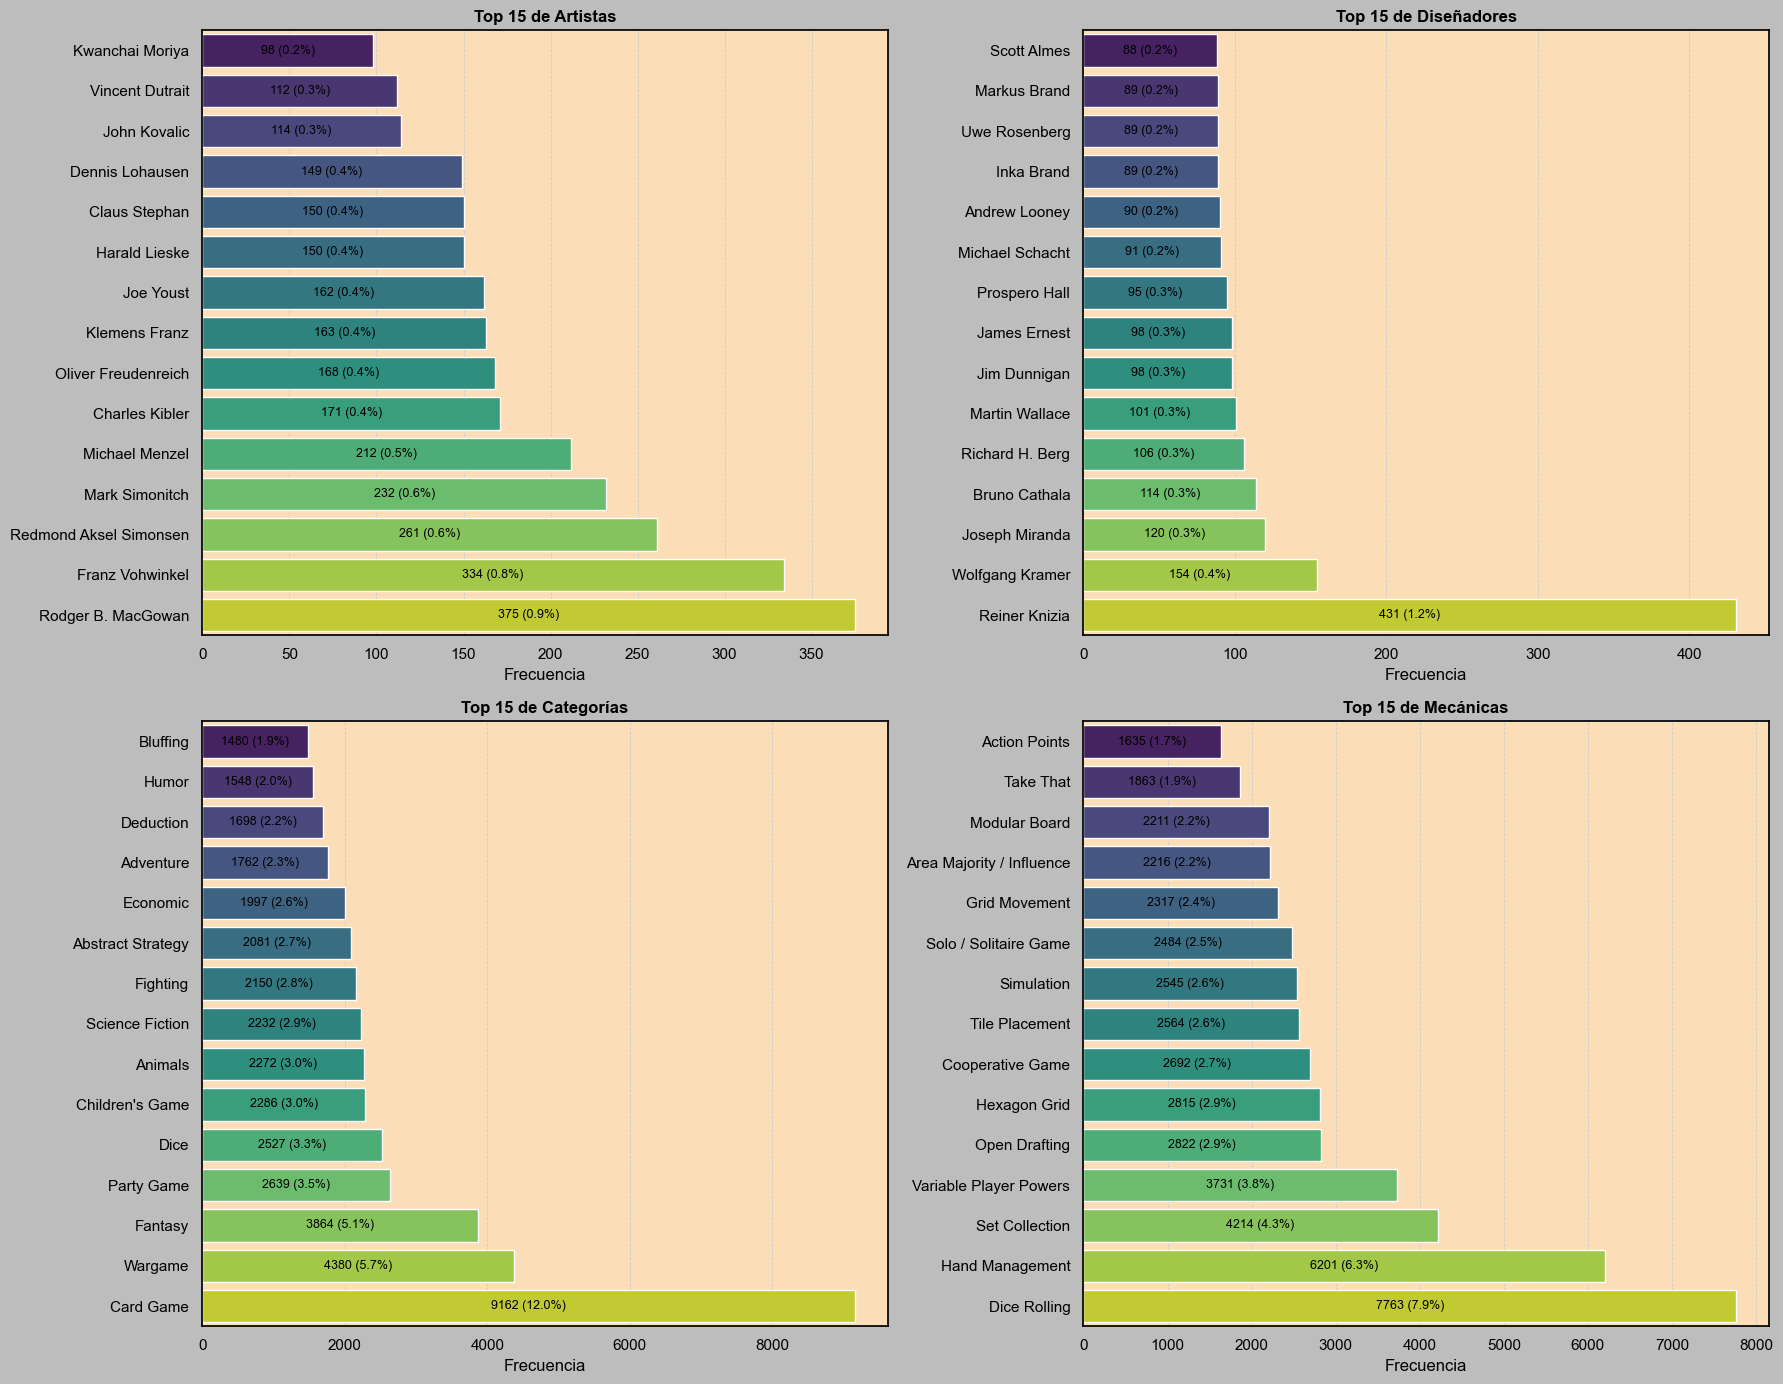

In [36]:
tablas = {
    'Artistas': artistas_filtrado['artists'],
    'Diseñadores': disenadores_filtrado['designers'],
    'Categorías': categorias_filtrado['categories'],
    'Mecánicas': mecanicas_filtrado['mechanisms']
}

# Llamar a la función
fn.graficar_top_items(tablas)

Una vez hemos determinado el top 15 de cada tabla, hacemos unas comparaciones por parejas. En este caso, vemos cual es el diseñador más adecuado para cada mecánica, teniendo en cuenta tanto la mejor nota como el número de juegos asociados en esa mecánica que tiene el autor.

In [37]:
mecanicas = ["Dice Rolling", "Hand Management", "Set Collection", "Variable Player Powers"]
display(fn.clasificacion_agrupada(bgg_juegos, mecanicas, mecanicas_filtrado, disenadores_filtrado, type='mean'))
display(fn.clasificacion_agrupada(bgg_juegos, mecanicas, mecanicas_filtrado, disenadores_filtrado, type='count'))

,mechanisms,designers,bayes_average
220,Dice Rolling,Ananda Gupta,8.04086
4958,Hand Management,Ananda Gupta,8.04086
9208,Set Collection,Andy Clautice,7.93731
13765,Variable Player Powers,Mathias Wigge,8.35456


,mechanisms,designers,bgg_id
2146,Dice Rolling,Jim Dunnigan,84
8089,Hand Management,Reiner Knizia,140
11208,Set Collection,Reiner Knizia,124
14555,Variable Player Powers,Steve Jackson (I),48


Hacemos la misma comparación con las categorías y los artistas, puesto que el arte de un juego suele estar más asociado a su temática que a su mecánica.

In [38]:
categorias = ["Science Fiction", "Fantasy", "Animals", "Dice"]
display(fn.clasificacion_agrupada(bgg_juegos, categorias, categorias_filtrado, artistas_filtrado, type='mean'))
display(fn.clasificacion_agrupada(bgg_juegos, categorias, categorias_filtrado, artistas_filtrado, type='count'))

,categories,artists,bayes_average
1639,Animals,Steffen Bieker,8.35456
2771,Dice,Jakub Dzikowski,8.47690
6983,Fantasy,Lucile Mathieu,8.29747
9852,Science Fiction,Derek Herring,8.23575


,categories,artists,bgg_id
1358,Animals,Oliver Freudenreich,25
3438,Dice,Oliver Freudenreich,25
5634,Fantasy,Franz Vohwinkel,38
10160,Science Fiction,Henning Ludvigsen,27


#### Top 100 ranking de juegos

Hacemos el mismo análisis de las tablas, solo tomando el top 100 de los juegos con mejor ranking.

In [39]:
top100_bgg_games = bgg_games[bgg_games['rank'].notnull()].sort_values('rank', ascending=True).head(100)
artistas_top100 = bgg_artistas[bgg_artistas['bgg_id'].isin(top100_bgg_games['bgg_id'])]
disenadores_top100 = bgg_disenadores[bgg_disenadores['bgg_id'].isin(top100_bgg_games['bgg_id'])]
categorias_top100 = bgg_categorias[bgg_categorias['bgg_id'].isin(top100_bgg_games['bgg_id'])]
mecanicas_top100 = bgg_mecanicas[bgg_mecanicas['bgg_id'].isin(top100_bgg_games['bgg_id'])]

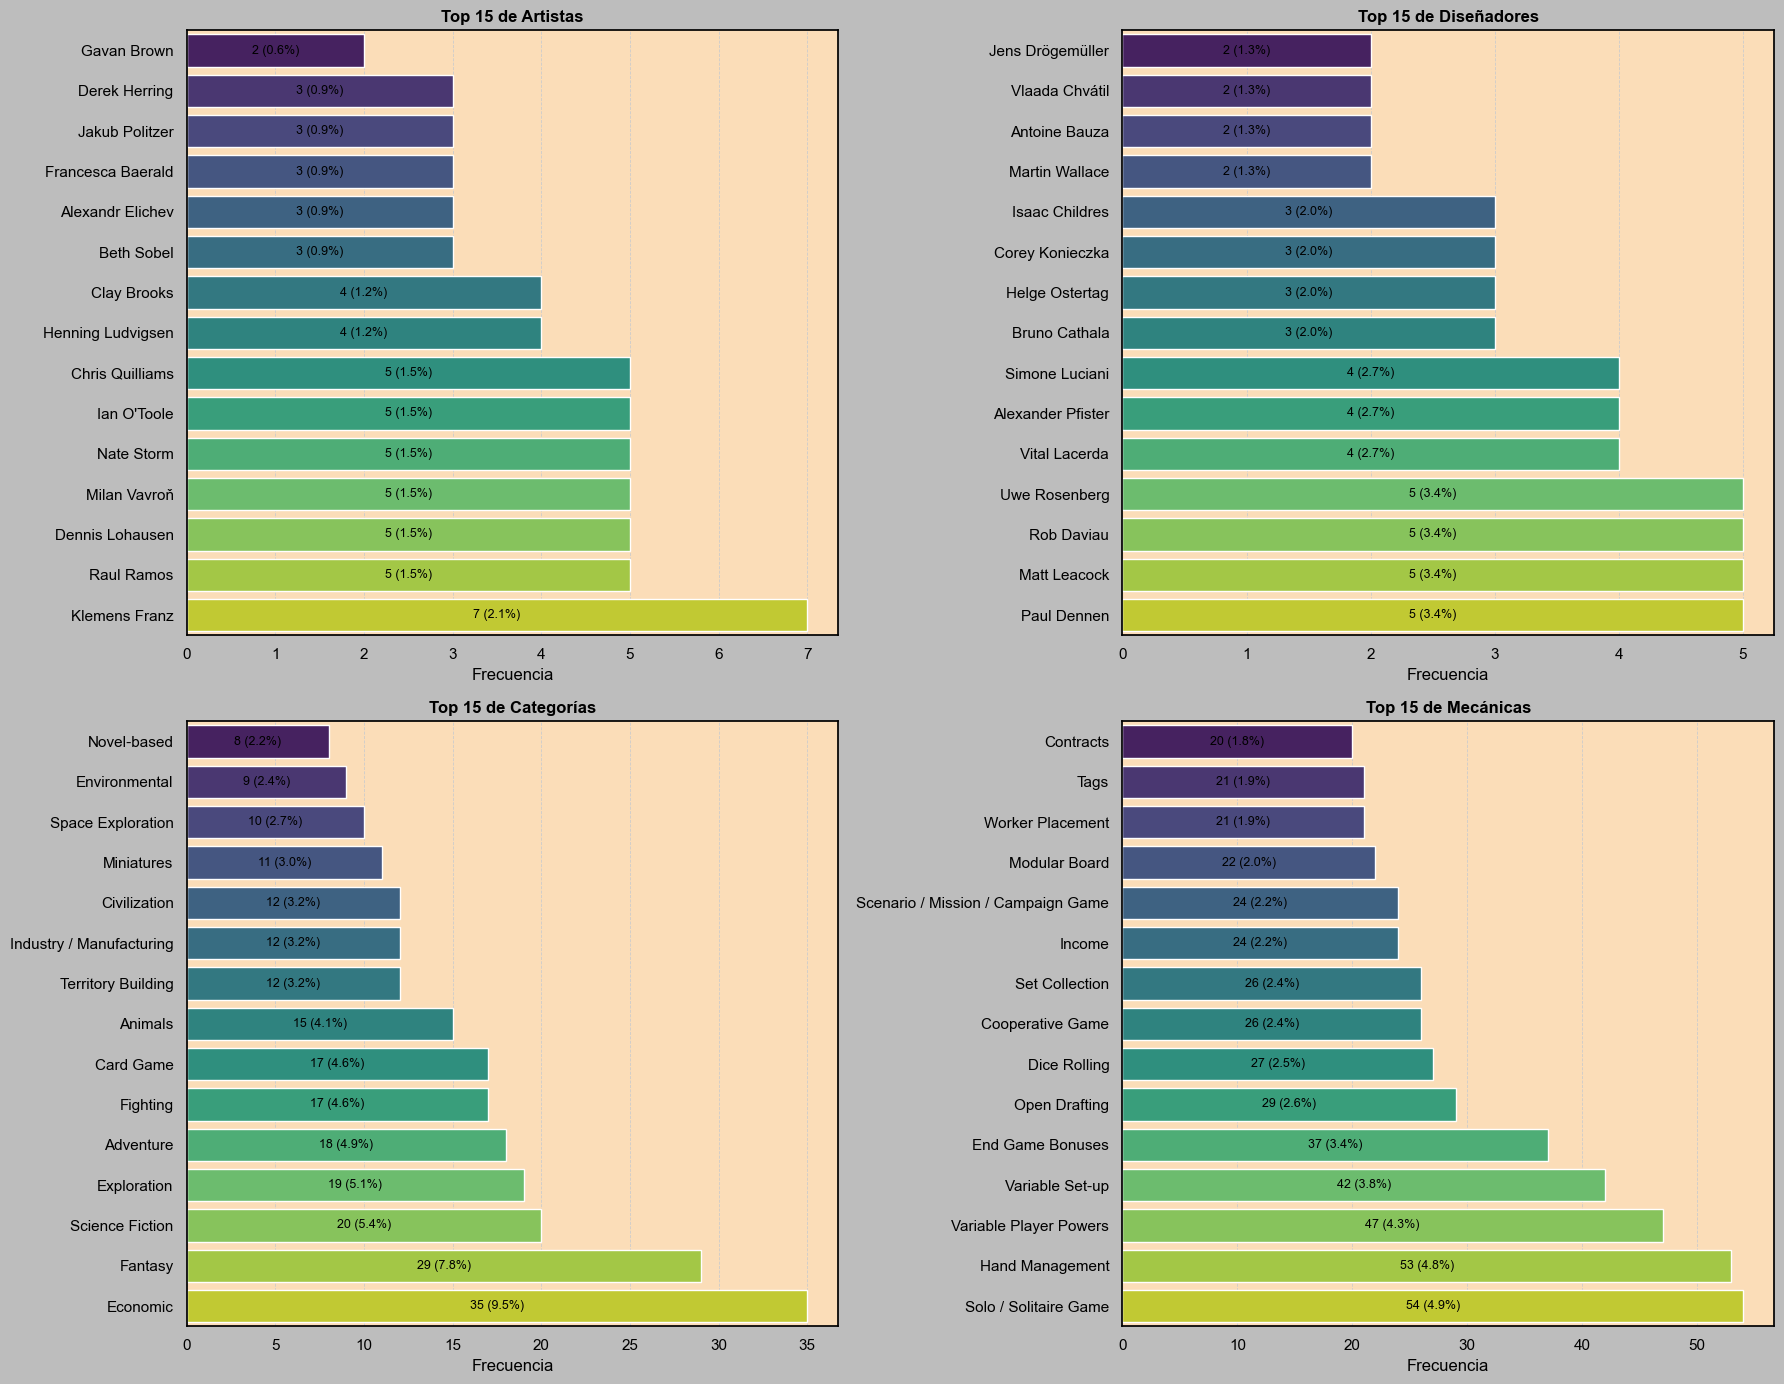

In [40]:
tablas_100 = {
    'Artistas': artistas_top100['artists'],
    'Diseñadores': disenadores_top100['designers'],
    'Categorías': categorias_top100['categories'],
    'Mecánicas': mecanicas_top100['mechanisms']
}

# Llamar a la función
fn.graficar_top_items(tablas_100)

Vemos como hay un aumento de la categoría Economics y Exploration que destaca con respecto al análisis global. En el caso de las mecánicas, se observa el aumento de la presencia del juego en solitario, cosa a destacar en juegos de alto peso.

#### Top 100 por interés

Por último, la comparación del top 15 de cada tabla con el valor que hemos calculado de *interest*, basado en la gente que tiene el juego (*owned*) o que lo desea (*wishing*).

In [41]:
bgg_juegos['interest'] = bgg_juegos['owned'] + bgg_juegos['wishing']
interest_sorted = bgg_juegos.sort_values('interest', ascending=False).head(100)
interest_sorted.head(5)

,bgg_id,rank,type,name,min_players,max_players,playingtime,minimum_age,release_year,average_rating,num_of_ratings,weight,num_of_weights,bayes_average,std_deviation,language_dependency,owned,wishing,interest
610,13,616.0,boardgame,Catan,3,4,120,10,1995,7.09086,142100,2.2826,8561,6.90388,1.50648,2: Some necessary text - easily memorized or s...,239917,8195,248112
170,30549,171.0,boardgame,Pandemic,2,4,45,8,2008,7.51349,134988,2.3942,6297,7.40404,1.33943,2: Some necessary text - easily memorized or s...,225741,11827,237568
235,822,238.0,boardgame,Carcassonne,2,5,45,7,2000,7.41627,139626,1.8850,8634,7.29882,1.31206,1: No necessary in-game text,223196,11051,234247
37,266192,38.0,boardgame,Wingspan,1,5,70,10,2019,7.99930,112700,2.4799,3736,7.84618,1.37484,4: Extensive use of text - massive conversion ...,180248,21934,202182
97,230802,98.0,boardgame,Azul,2,4,45,8,2017,7.71518,108193,1.7743,2915,7.60569,1.16819,1: No necessary in-game text,183232,16199,199431


In [42]:
artistas_interest = bgg_artistas[bgg_artistas['bgg_id'].isin(interest_sorted['bgg_id'])]
disenadores_interest = bgg_disenadores[bgg_disenadores['bgg_id'].isin(interest_sorted['bgg_id'])]
categorias_interest = bgg_categorias[bgg_categorias['bgg_id'].isin(interest_sorted['bgg_id'])]
mecanicas_interest = bgg_mecanicas[bgg_mecanicas['bgg_id'].isin(interest_sorted['bgg_id'])]

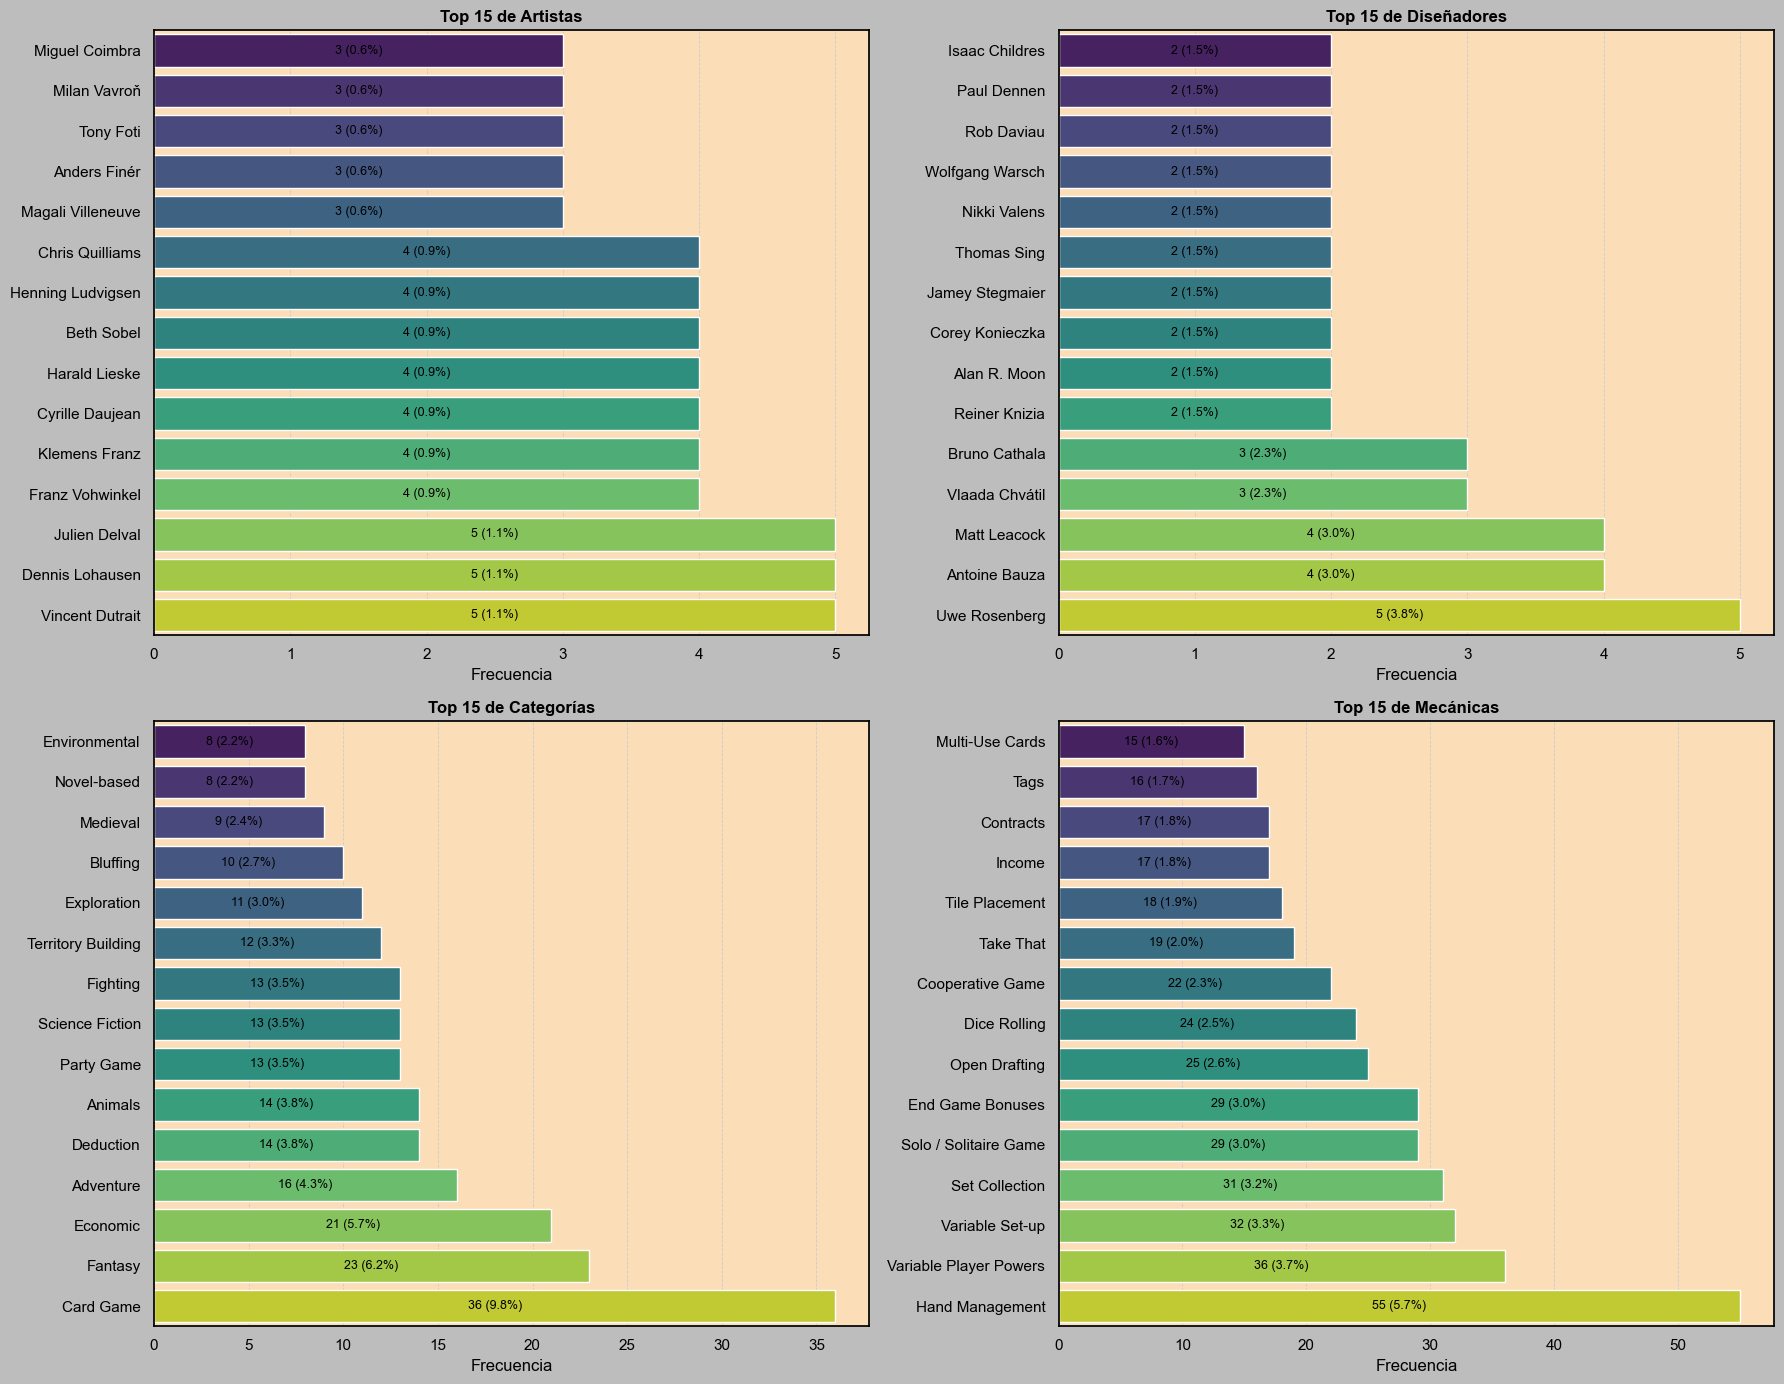

In [43]:
tablas_interest = {
    'Artistas': artistas_interest['artists'],
    'Diseñadores': disenadores_interest['designers'],
    'Categorías': categorias_interest['categories'],
    'Mecánicas': mecanicas_interest['mechanisms']
}

# Llamar a la función
fn.graficar_top_items(tablas_interest)

En cuanto a mecánicas, vemos que se mantiene Hand Management y Variable Player Powers, y destacan otras como Set Collection. Aquí vuelve a parecer Card Game en categorías.

### Análisis multivariante

Ahora procedemos a hacer el analisis de multiples variables al mismo tiempo. Para ello eliminamos algunas de estas variables puesto que, por su naturaleza, no son fáciles de tratar o no nos aportan información relevante.

In [44]:
# Crear una copia del dataframe eliminando filas con valores nulos
df_plot = bgg_juegos.dropna().copy()

# Eliminar columnas que no se van a usar en el análisis multivariante
df_plot.drop(
    columns=[
        'bgg_id', 'type', 'name', 'num_of_ratings', 'num_of_weights',
        'std_deviation', 'owned', 'wishing', 'language_dependency',
        'bayes_average', "interest"
    ],
    inplace=True
)

Hacemos una matriz de correlación entre las diferentes columnas para ver cuales son aquellas que, a priori, presentan una relación más cercana.

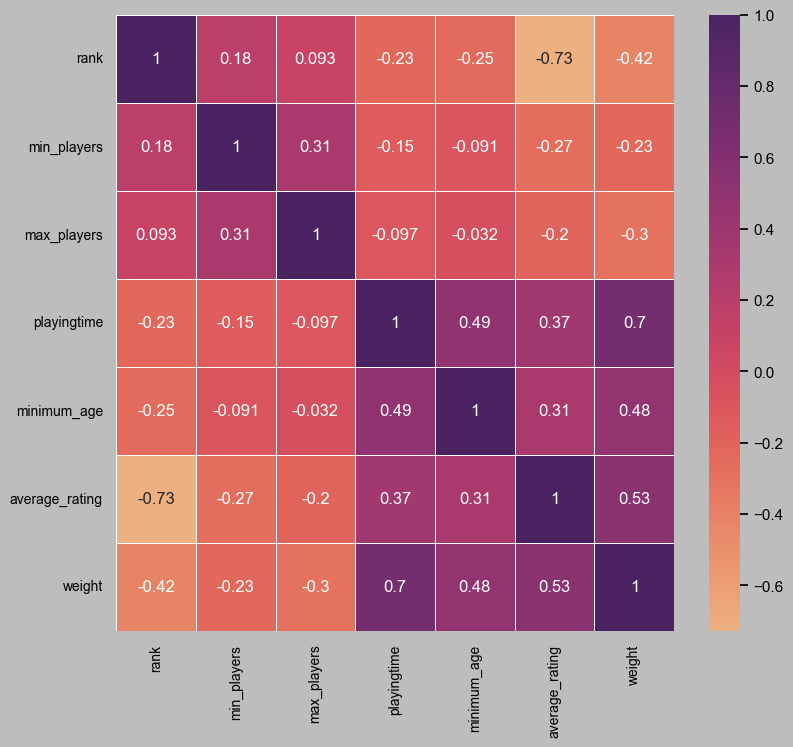

In [45]:
df_correlacion = df_plot.copy()
df_correlacion.drop(columns=['release_year'], inplace=True)

correlation_matrix = df_correlacion.select_dtypes(include=[np.number]).corr(method='spearman')

plt.figure(figsize=(9, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='flare',
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 12}
)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

Relaciones interesantes:
- Relación alta inversa entre el *average_rating* y el *rank*. Tiene sentido porque el segundo es un calculo indirecto del primero.
- Relación alta directa con el peso frente a tiempo de juego, la edad minima y valoración. Esto significa que los juegos pesados tiene una mayor duración, necesitan que el jugador sea mayor y tienden a tener una mejor valoración.
- Relacion directa entre minimo y máximo de jugadores, tienden a subir los dos en paralelo.
- Relación inversa ligera entre peso y nº de jugadores. Esto significa que a mayor dificultad, menor el nº de jugadores recomendados.
- Relación inversa ligera entre la valoración y nº de jugadores. Esto significa que a mejor valorado un juego, menor el nº de jugadores recomendados.

Vamos a hacer una representación en un scatterplot de todas estas bivariantes y vamos a estudiar aquellas que hemos marcado como relevantes.

In [46]:
# Crear una variable categórica a partir de la valoración media
# Se divide el rango de "average_rating" en intervalos para facilitar la visualización
df_plot['rating_cat'] = pd.cut(
    df_plot['average_rating'],
    bins=[0, 2, 4, 6, 8, 10],
    labels=['0-2', '2-4', '4-6', '6-8', '8-10'],
    include_lowest=True
)

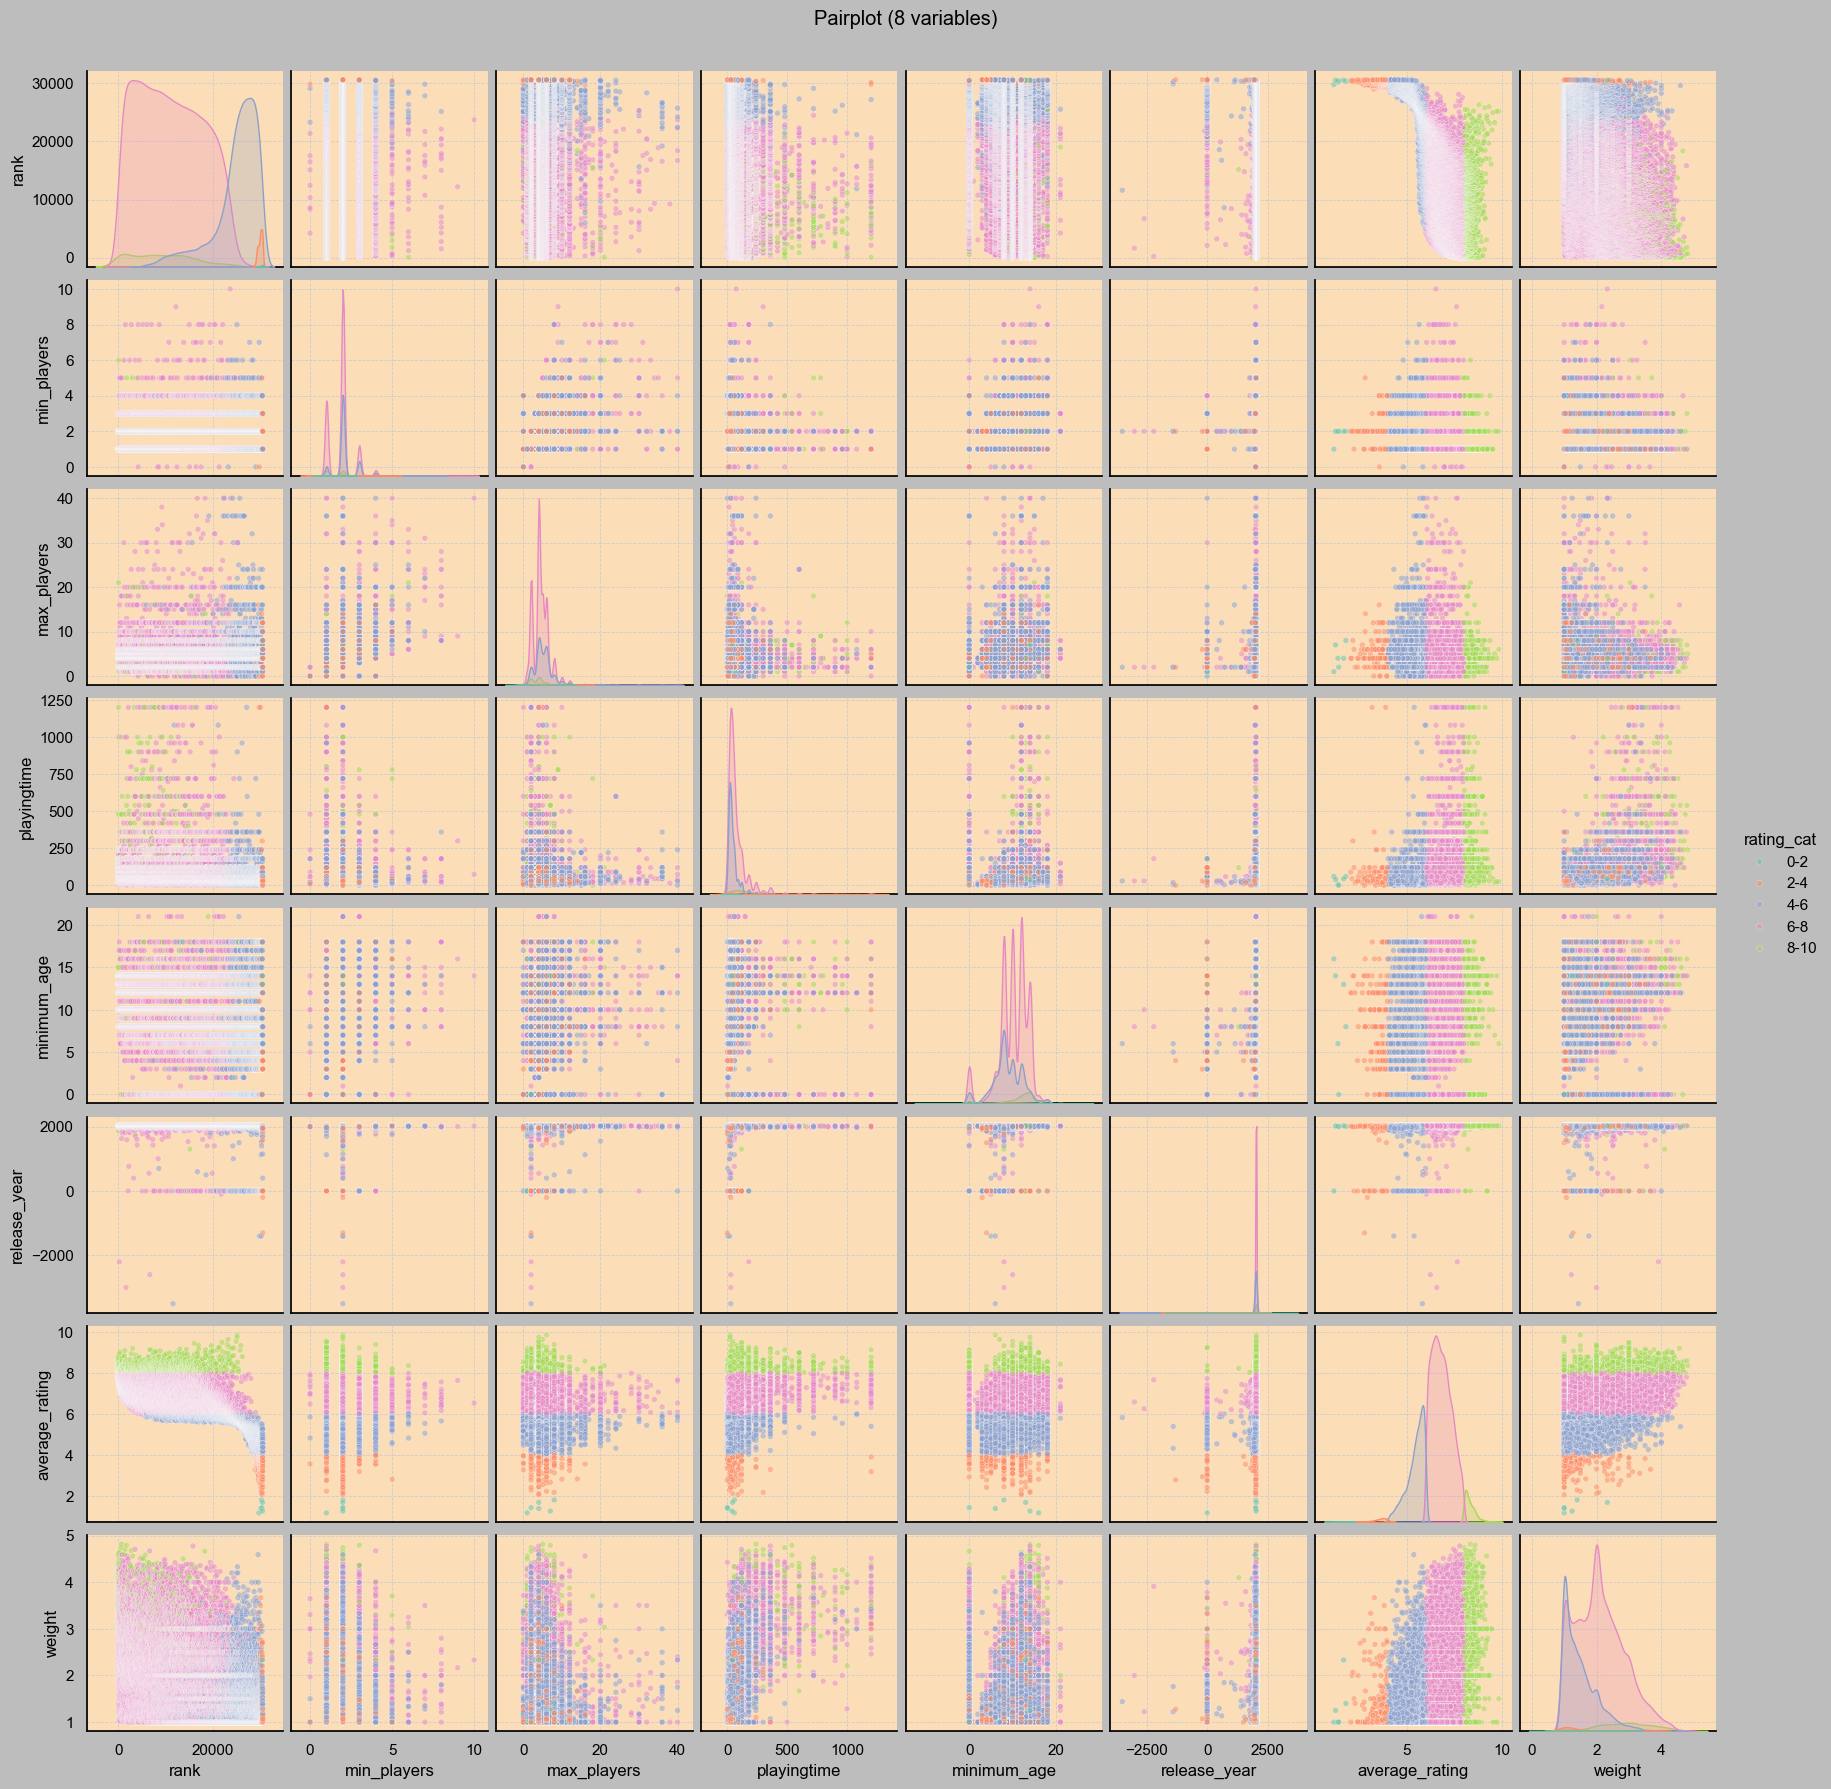

In [47]:
g = fn.pairplot_simetrico(
    df_plot,
    corner=False,
    hue='rating_cat',
    diag_kind='kde',
    diag_kws={'fill': True}  # evita pasar 'bins' a KDE
)


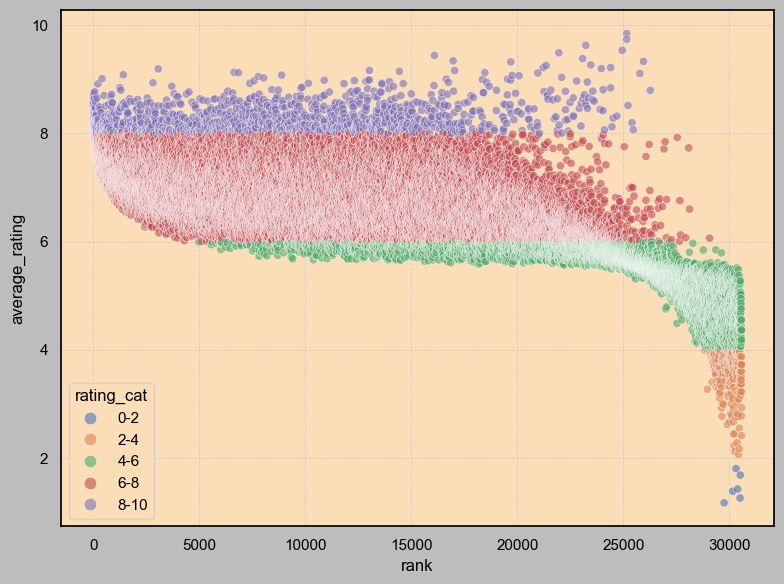

In [48]:
fn.subplot_pairplot(df_plot, 'rank', 'average_rating', 'rating_cat', alpha=0.6)

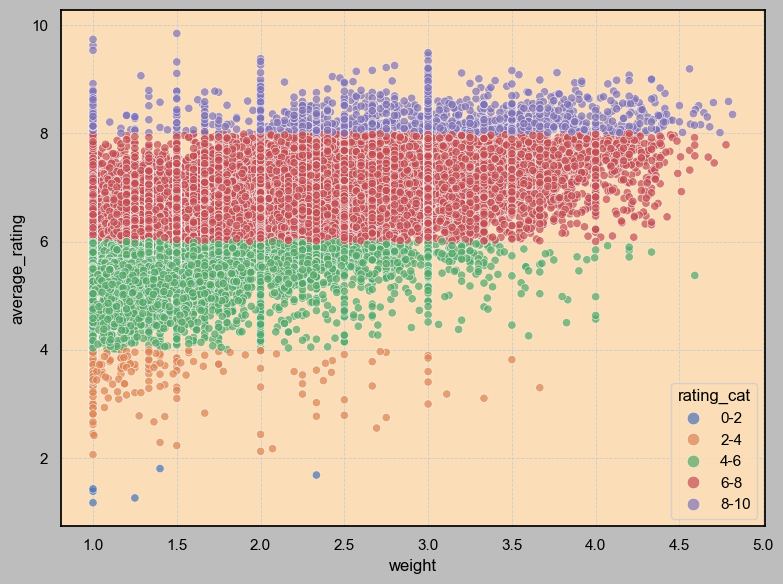

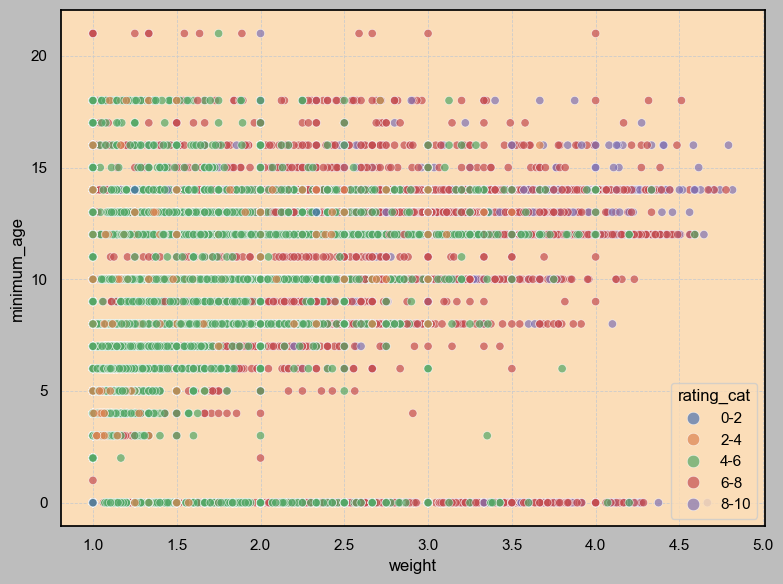

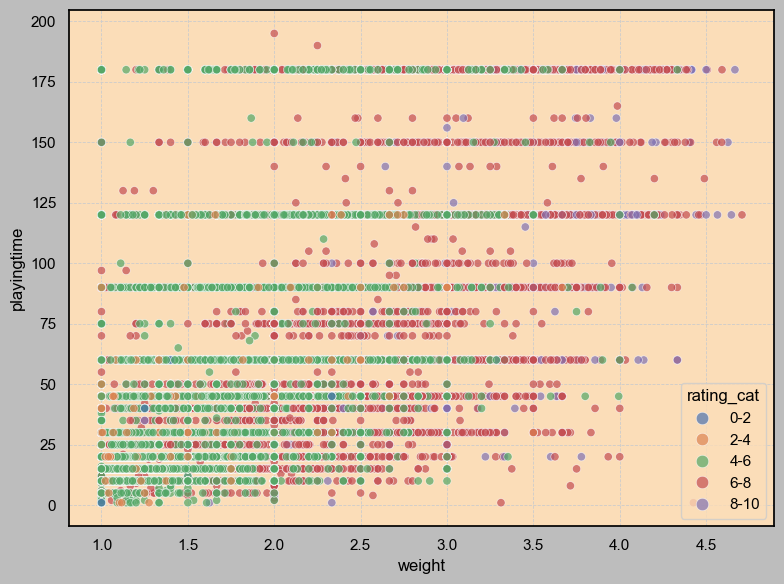

In [49]:
fn.subplot_pairplot(df_plot, 'weight', 'average_rating', 'rating_cat', alpha=0.7)
fn.subplot_pairplot(df_plot, 'weight', 'minimum_age', 'rating_cat', alpha=0.7)
fn.subplot_pairplot(df_plot[df_plot['playingtime'] < 200], 'weight', 'playingtime', 'rating_cat', alpha=0.7)

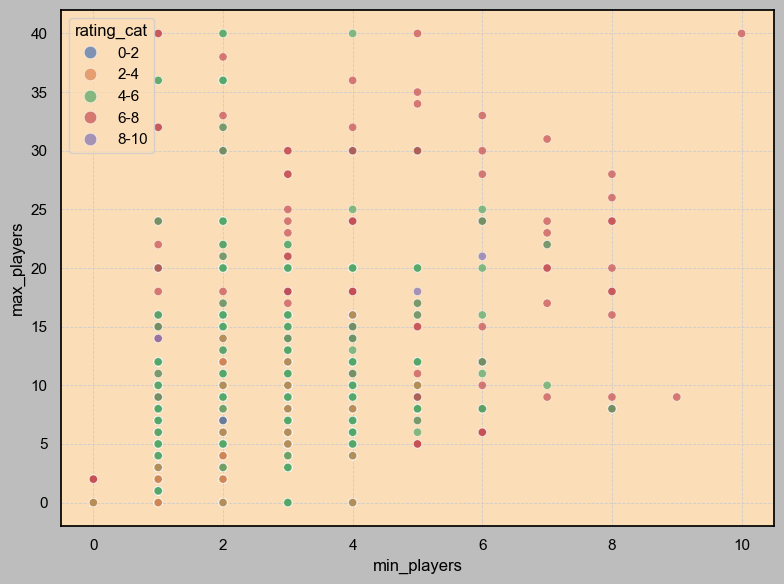

,min_players,max_players,conteo
0,2,4,6463
1,2,2,4202
2,2,6,3142
3,1,4,2503
4,2,5,2472
5,3,6,1048
6,1,2,930
7,3,5,875
8,1,6,819
9,2,8,797


In [50]:
# Relación entre el mínimo y máximo de jugadores, coloreando por categoría de valoración
fn.subplot_pairplot(df_plot, 'min_players', 'max_players', 'rating_cat', alpha=0.7)

# Conteo de combinaciones únicas de mínimo y máximo de jugadores
conteo_parejas_jugadores = (
    df_plot
    .groupby(['min_players', 'max_players'])
    .size()
    .reset_index(name='conteo')
    .sort_values('conteo', ascending=False)
    .reset_index(drop=True)
)

# Mostrar las combinaciones más frecuentes
conteo_parejas_jugadores.head(10)


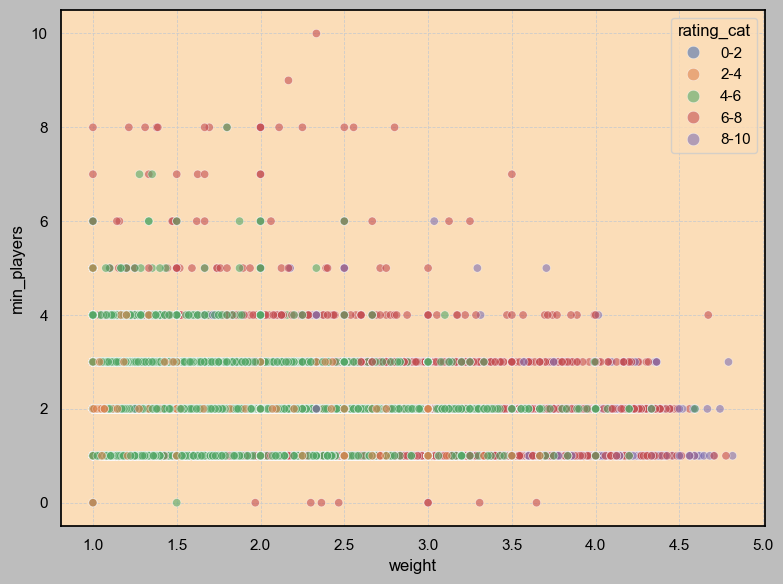

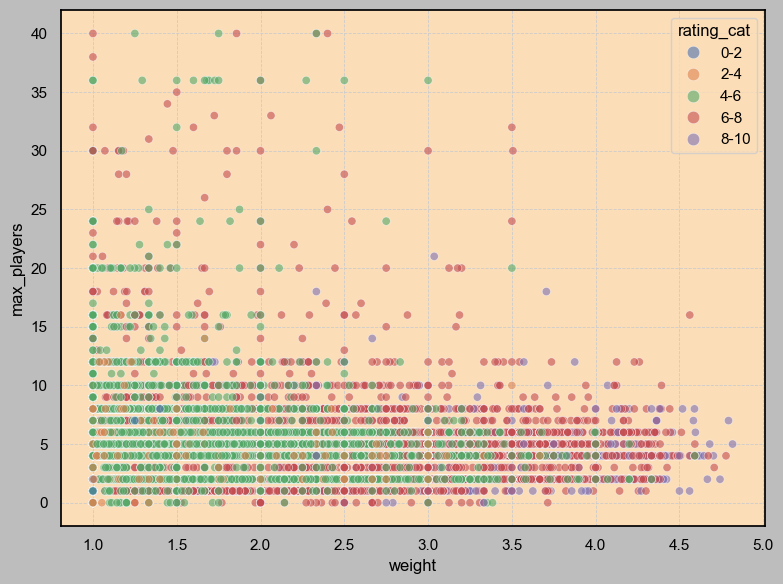

In [51]:
fn.subplot_pairplot(df_plot, 'weight', 'min_players', 'rating_cat', alpha=0.6)
fn.subplot_pairplot(df_plot, 'weight', 'max_players', 'rating_cat', alpha=0.6)

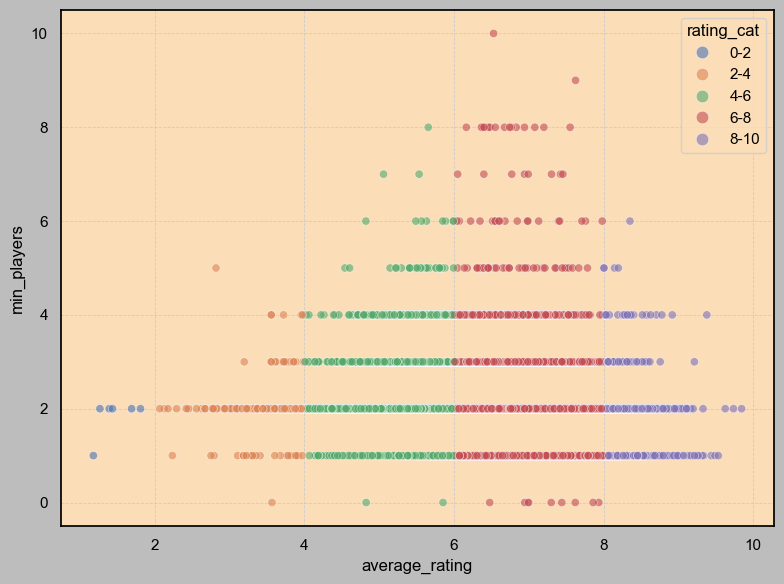

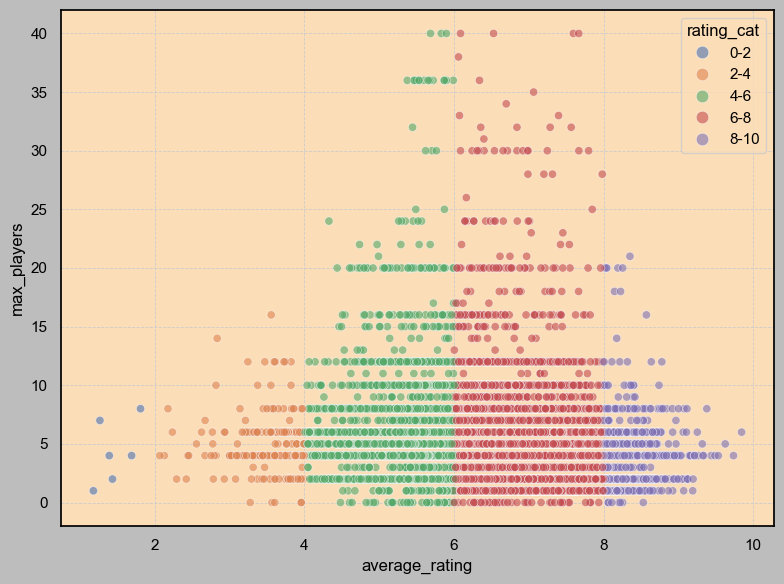

In [52]:
fn.subplot_pairplot(df_plot, 'average_rating', 'min_players', 'rating_cat', alpha=0.6)
fn.subplot_pairplot(df_plot, 'average_rating', 'max_players', 'rating_cat', alpha=0.6)

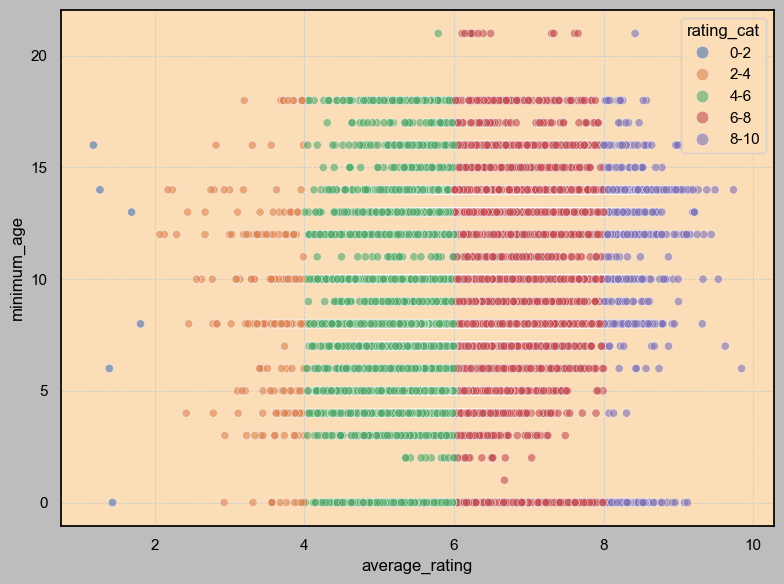

In [53]:
fn.subplot_pairplot(df_plot, 'average_rating', 'minimum_age', 'rating_cat', alpha=0.6)

## Conclusiones finales

- Número de jugadores: 2 a 4 jugadores
- Edad minima: 10-11 años
- Categoría (Género): Fantasia o Económico
- Mecánicas: Dados, Manejo de mano, Set Collector
- Artistas (para Fantasia): Lucile Mathieu y/o Franz Vohwinkel
- Diseñador (por las mécanicas más frecuentes): Reiner Knizia